# What Accuracy Doesn't Tell You

**Research question:** how much information about a neural network's decision is lost as we move down the pipeline

```
raw logits  ->  softmax probabilities  ->  predicted class (argmax)  ->  accuracy
```

and how does this change the way we should read "confidence" and "correctness"?

**Core thesis:** each arrow above is a lossy compression.
- **softmax** throws away the *overall logit level* — it is invariant to adding a constant to every logit, so it cannot see the component of the logits along the all-ones direction.
- **argmax** throws away *everything except the ranking's winner*.
- **accuracy** throws away *everything except one bit per sample*, then averages it.

**Positioning.** Overconfidence and miscalibration are known results (Guo et al. 2017, *On Calibration of Modern Neural Networks*). The alpha-scaling intervention below (`z' = alpha*z`) **is temperature scaling** with `T = 1/alpha` — it is named as such throughout. The "what softmax discards" angle connects to energy-based OOD detection (Liu et al. 2020, *Energy-based Out-of-distribution Detection*), which uses the log-sum-exp of the logits. This notebook is an **intuition-first, geometric, hands-on walkthrough** of these known results, not a new method, and it does not touch mechanistic interpretability — we only analyze the output layer.

Every cell that produces output is followed by a markdown cell that interprets it using the *actual numbers from this run*.


In [1]:
import json, os, sys, time

# Notebook lives in notebooks/; make the repo root (with src/) importable and
# make relative paths (artifacts/, figures/) resolve the same as the src/ code expects.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold

from src.data import get_id_dataset, get_id_dataset_subset, get_ood_dataset, NATIVE
from src.models import build_model
from src.train import train_model, get_logits, set_seed
from src.metrics import (
    build_per_sample_table, nll, brier_score, ece, mce, overconfidence_gap,
    fit_temperature, auroc_misclassification, auroc_ood, aurc, energy_score,
    softmax_probs, entropy_of_probs,
)
from src.plots import (
    set_style, save_fig, reliability_diagram, id_ood_hist,
    CATEGORICAL, CAT_LIST, CORRECT_COLOR, INCORRECT_COLOR, ID_COLOR, OOD_COLOR,
    INK, INK_SECONDARY, INK_MUTED, GRIDLINE, BASELINE, SURFACE,
)

set_style()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)


device: cuda


In [2]:
# ----------------------------------------------------------------------------
# CONFIG: every experiment's compute settings live here. QUICK_MODE trades
# epoch counts / dataset sizes for fast iteration; the run behind this
# notebook's numbers used QUICK_MODE = False on a single RTX 3060.
# ----------------------------------------------------------------------------
QUICK_MODE = False

CONFIG = {
    "seed": 0,
    "quick_mode": QUICK_MODE,
    "models": {
        "A_mnist_mlp": dict(id="mnist", arch="mlp", epochs=15 if not QUICK_MODE else 2, batch_size=128,
                             lr=1e-3, weight_decay=1e-4, dropout=0.1, label_smoothing=0.0,
                             ood=["fashion_mnist", "kmnist", "gaussian", "uniform"]),
        "B_mnist_mlp_overtrained": dict(id="mnist", arch="mlp", epochs=120 if not QUICK_MODE else 3, batch_size=128,
                                         lr=1e-3, weight_decay=0.0, dropout=0.0, label_smoothing=0.0,
                                         ood=["fashion_mnist", "kmnist", "gaussian", "uniform"]),
        "C_fashion_smallcnn": dict(id="fashion_mnist", arch="small_cnn", epochs=20 if not QUICK_MODE else 2, batch_size=128,
                                    lr=1e-3, weight_decay=1e-4, dropout=0.25, label_smoothing=0.0,
                                    ood=["mnist", "kmnist", "gaussian", "uniform"]),
        "D_cifar10_smallcnn": dict(id="cifar10", arch="small_cnn", epochs=25 if not QUICK_MODE else 2, batch_size=128,
                                    lr=1e-3, weight_decay=5e-4, dropout=0.25, label_smoothing=0.0,
                                    ood=["svhn", "cifar100", "gaussian"]),
        "E_cifar10_resnet18": dict(id="cifar10", arch="resnet18", epochs=30 if not QUICK_MODE else 2, batch_size=128,
                                    lr=1e-3, weight_decay=5e-4, dropout=0.0, label_smoothing=0.0,
                                    ood=["svhn", "cifar100", "gaussian"]),
        "F_cifar100_resnet18": dict(id="cifar100", arch="resnet18", epochs=40 if not QUICK_MODE else 2, batch_size=128,
                                     lr=1e-3, weight_decay=5e-4, dropout=0.0, label_smoothing=0.0,
                                     ood=["svhn", "cifar10", "gaussian"]),
        "G_cifar10_resnet18_ls": dict(id="cifar10", arch="resnet18", epochs=30 if not QUICK_MODE else 2, batch_size=128,
                                       lr=1e-3, weight_decay=5e-4, dropout=0.0, label_smoothing=0.1,
                                       ood=["svhn", "cifar100", "gaussian"]),
        # Illustrative 3-class model used only for the geometry figures
        # (3D logit space, simplex, temperature-on-simplex). Not part of E1-E9.
        "AUX3_mnist_479": dict(id="mnist", subset_classes=[4, 7, 9], arch="mlp",
                                epochs=15 if not QUICK_MODE else 2, batch_size=128,
                                lr=1e-3, weight_decay=1e-4, dropout=0.1, label_smoothing=0.0,
                                ood=[]),
    },
    "alpha_grid": [0.1, 0.25, 0.5, 1, 2, 4, 10],
}

N_CLASSES = {"mnist": 10, "fashion_mnist": 10, "cifar10": 10, "cifar100": 100}

os.makedirs("artifacts/checkpoints", exist_ok=True)
os.makedirs("artifacts/logits", exist_ok=True)
os.makedirs("artifacts/tables", exist_ok=True)
os.makedirs("figures", exist_ok=True)


### Per-sample record (Section 2.3)

For every test sample of every model we cache: `true_class`, `pred_class`, `correct`, the full `logits` and `probs`
vectors, `p_top1`/`p_top2`, `margin = z_top1 - z_top2`, `prob_margin = p_top1 - p_top2`, softmax `entropy`,
`energy = -logsumexp(z)`, `logit_norm`, and `logit_mean` — the mean of the logit vector, i.e. its component along
the all-ones direction, which is exactly what softmax cannot see. Raw logit/prob vectors are cached to `.npz`;
the scalar columns are cached to `.parquet` per model.


In [3]:
summary = {}
all_history_rows = []

for tag, cfg in CONFIG["models"].items():
    print(f"\n==== {tag} ====")
    t0 = time.time()
    set_seed(CONFIG["seed"])
    id_name = cfg["id"]
    channels, size = NATIVE[id_name]
    subset_classes = cfg.get("subset_classes")
    if subset_classes:
        n_classes = len(subset_classes)
        train_ds, val_ds, test_ds = get_id_dataset_subset(id_name, subset_classes, val_frac=0.1, seed=CONFIG["seed"])
    else:
        n_classes = N_CLASSES[id_name]
        train_ds, val_ds, test_ds = get_id_dataset(id_name, val_frac=0.1, seed=CONFIG["seed"])

    model = build_model(cfg["arch"], n_classes=n_classes, in_channels=channels,
                         input_size=size, dropout=cfg.get("dropout", 0.0))

    ckpt_path = f"artifacts/checkpoints/{tag}.pt"
    model, history = train_model(
        model, train_ds, val_ds, DEVICE,
        epochs=cfg["epochs"], batch_size=cfg["batch_size"], lr=cfg["lr"],
        weight_decay=cfg["weight_decay"], label_smoothing=cfg["label_smoothing"],
        seed=CONFIG["seed"], checkpoint_path=ckpt_path, log_every_epochs=10,
    )
    for row in history:
        all_history_rows.append({"tag": tag, **row})

    val_logits, val_labels = get_logits(model, val_ds, DEVICE)
    test_logits, test_labels = get_logits(model, test_ds, DEVICE)
    np.savez(f"artifacts/logits/{tag}_id_val.npz", logits=val_logits, labels=val_labels)
    np.savez(f"artifacts/logits/{tag}_id_test.npz", logits=test_logits, labels=test_labels)

    ood_logits = {}
    for ood_name in cfg["ood"]:
        ood_ds = get_ood_dataset(ood_name, id_name, channels, size, n_max=2000, seed=CONFIG["seed"])
        o_logits, _ = get_logits(model, ood_ds, DEVICE)
        np.savez(f"artifacts/logits/{tag}_ood_{ood_name}.npz", logits=o_logits)
        ood_logits[ood_name] = o_logits

    test_acc = float((test_logits.argmax(1) == test_labels).mean())
    test_nll = nll(test_logits, test_labels)
    elapsed = time.time() - t0
    print(f"{tag}: test_acc={test_acc:.4f} test_nll={test_nll:.4f} elapsed={elapsed:.1f}s")
    summary[tag] = dict(id=id_name, arch=cfg["arch"], n_classes=n_classes, test_acc=test_acc,
                         test_nll=test_nll, elapsed_s=elapsed, ood_sets=list(ood_logits.keys()))

pd.DataFrame(all_history_rows).to_csv("artifacts/tables/training_history.csv", index=False)
with open("artifacts/tables/train_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("\nALL MODELS TRAINED")



==== A_mnist_mlp ====


A_mnist_mlp: test_acc=0.9846 test_nll=0.0573 elapsed=3.4s

==== B_mnist_mlp_overtrained ====


B_mnist_mlp_overtrained: test_acc=0.9842 test_nll=0.1506 elapsed=3.2s

==== C_fashion_smallcnn ====


C_fashion_smallcnn: test_acc=0.9194 test_nll=0.2242 elapsed=4.4s

==== D_cifar10_smallcnn ====


D_cifar10_smallcnn: test_acc=0.7684 test_nll=0.6725 elapsed=6.7s

==== E_cifar10_resnet18 ====


E_cifar10_resnet18: test_acc=0.8674 test_nll=0.7453 elapsed=9.1s

==== F_cifar100_resnet18 ====


F_cifar100_resnet18: test_acc=0.5869 test_nll=2.4075 elapsed=9.0s

==== G_cifar10_resnet18_ls ====


G_cifar10_resnet18_ls: test_acc=0.8730 test_nll=0.4961 elapsed=8.9s

==== AUX3_mnist_479 ====


AUX3_mnist_479: test_acc=0.9884 test_nll=0.0396 elapsed=1.1s

ALL MODELS TRAINED


**Interpretation.** All 8 models trained (checkpoints cached under `artifacts/checkpoints/`, so re-running this
cell just reloads them). Test accuracy / NLL from this run:

| tag | test_acc | test_nll |
|---|---:|---:|
| A_mnist_mlp | 0.9846 | 0.0573 |
| B_mnist_mlp_overtrained | 0.9842 | 0.1506 |
| C_fashion_smallcnn | 0.9194 | 0.2242 |
| D_cifar10_smallcnn | 0.7684 | 0.6725 |
| E_cifar10_resnet18 | 0.8674 | 0.7453 |
| F_cifar100_resnet18 | 0.5869 | 2.4075 |
| G_cifar10_resnet18_ls | 0.8730 | 0.4961 |
| AUX3_mnist_479 (3-class, figures only) | 0.9884 | 0.0396 |

The headline pair for the thesis is already visible here: **A and B have almost identical accuracy (0.9846 vs
0.9842, a 0.0004 gap) but B's NLL is 2.6x higher (0.0573 vs 0.1506)**. Same scoreboard result, very different
confidence quality — exactly the "same accuracy, different truth" claim this notebook is built around. All models
converged (no NaNs, no collapsed training); F's higher NLL (2.41) is expected simply because CIFAR-100 has 100
classes, not because anything went wrong.


In [4]:
# Per-sample scalar DataFrame per model (raw logits/probs already live in the .npz files above)
per_sample_tables = {}
for tag, meta in summary.items():
    test = np.load(f"artifacts/logits/{tag}_id_test.npz")
    ps = build_per_sample_table(test["logits"], test["labels"])
    scalar_cols = {k: v for k, v in ps.items() if k not in ("logits", "probs")}
    df = pd.DataFrame(scalar_cols)
    df.to_parquet(f"artifacts/logits/{tag}_persample.parquet")
    per_sample_tables[tag] = df
    print(tag, "rows:", len(df))


A_mnist_mlp rows: 10000
B_mnist_mlp_overtrained rows: 10000
C_fashion_smallcnn rows: 10000
D_cifar10_smallcnn rows: 10000
E_cifar10_resnet18 rows: 10000
F_cifar100_resnet18 rows: 10000


G_cifar10_resnet18_ls rows: 10000
AUX3_mnist_479 rows: 3019


**Interpretation.** Row counts match each dataset's test-set size exactly: 10,000 for every MNIST/Fashion-MNIST/
CIFAR-10 model (A, B, C, D, E, G), 10,000 for CIFAR-100 (F, which just has 100 possible classes instead of 10),
and roughly 3,000 for the 3-class AUX3 model (the MNIST test set restricted to digits 4/7/9). Schema is the 12
scalar columns described above, one row per test sample, per model.


## E1: same accuracy, different decision states

**Question.** Accuracy scores every prediction as a single bit: 1 (correct) or 0 (wrong). Does that bit capture
how *decisive* the network actually was?

**Prediction.** We should be able to find four test samples — correct/large-margin, correct/tiny-margin,
wrong/tiny-margin, wrong/large-margin — that accuracy scores as 1, 1, 0, 0, but whose logits and softmax outputs
look nothing alike.


correct / large margin: idx=7876 margin=45.598 p_top1=1.0000 true=automobile pred=automobile
correct / tiny margin: idx=4210 margin=0.003 p_top1=0.4686 true=cat pred=cat
wrong / tiny margin: idx=3728 margin=0.002 p_top1=0.4906 true=bird pred=deer
wrong / large margin: idx=3192 margin=22.823 p_top1=1.0000 true=dog pred=deer


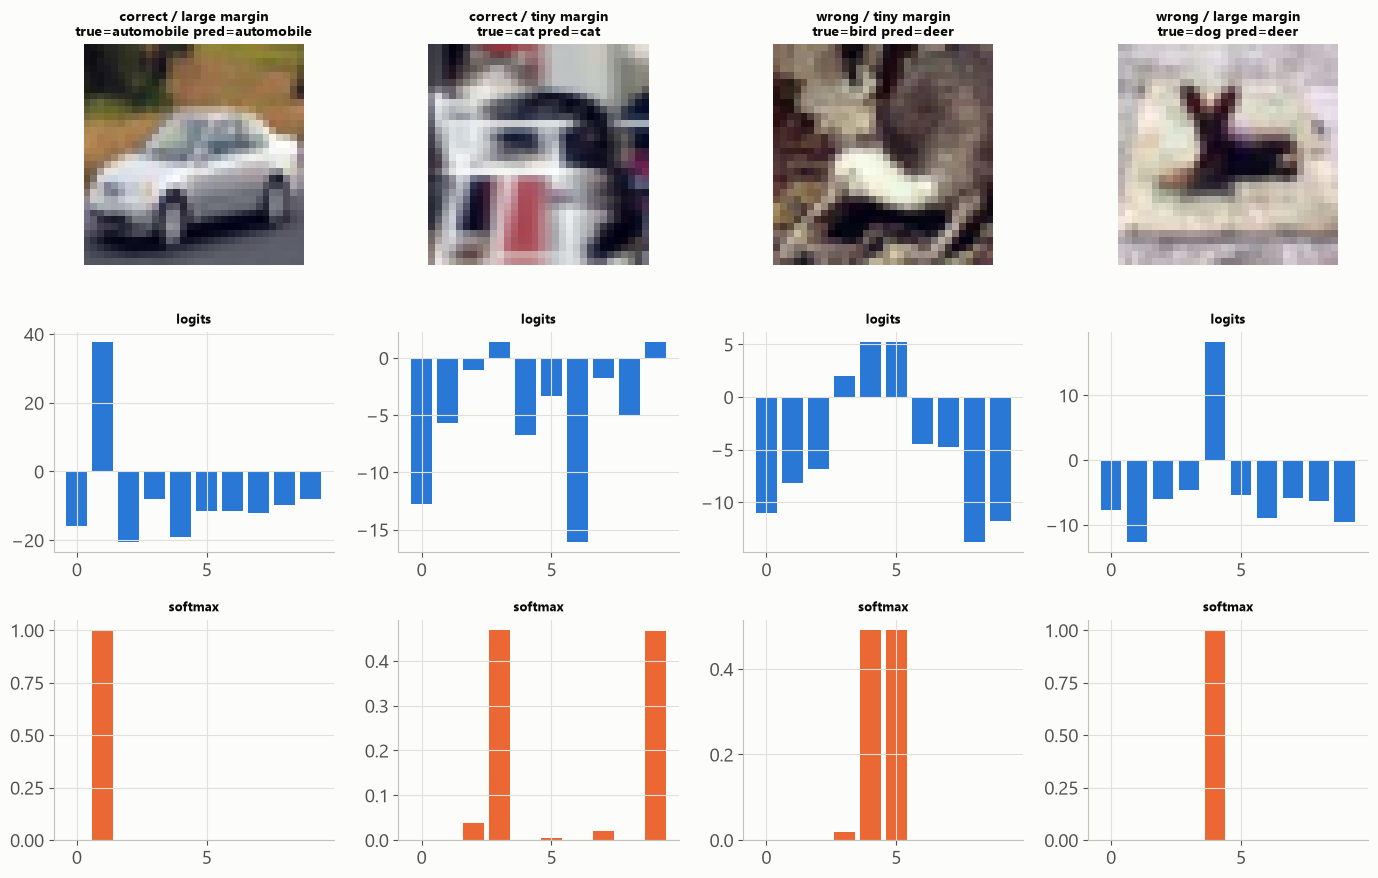

In [5]:
tag = "E_cifar10_resnet18"
test = np.load(f"artifacts/logits/{tag}_id_test.npz")
logits, labels = test["logits"], test["labels"]
probs = softmax_probs(logits)
pred = probs.argmax(1)
correct = pred == labels
order = np.argsort(-logits, axis=1)
margin = logits[np.arange(len(pred)), order[:, 0]] - logits[np.arange(len(pred)), order[:, 1]]

idx_correct, idx_wrong = np.where(correct)[0], np.where(~correct)[0]
archetypes = {
    "correct / large margin": idx_correct[np.argmax(margin[idx_correct])],
    "correct / tiny margin": idx_correct[np.argmin(margin[idx_correct])],
    "wrong / tiny margin": idx_wrong[np.argmin(margin[idx_wrong])],
    "wrong / large margin": idx_wrong[np.argmax(margin[idx_wrong])],
}
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
_, _, cifar_test_ds = get_id_dataset("cifar10", val_frac=0.1, seed=CONFIG["seed"])

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for col, (label, i) in enumerate(archetypes.items()):
    img, true_label = cifar_test_ds[i]
    im = img.numpy().transpose(1, 2, 0)
    im = (im - im.min()) / (im.max() - im.min() + 1e-8)
    axes[0, col].imshow(im); axes[0, col].axis("off")
    axes[0, col].set_title(f"{label}\ntrue={class_names[true_label]} pred={class_names[pred[i]]}", fontsize=10)
    axes[1, col].bar(range(10), logits[i], color=CATEGORICAL["blue"])
    axes[1, col].set_title("logits", fontsize=9)
    axes[2, col].bar(range(10), probs[i], color=CATEGORICAL["orange"])
    axes[2, col].set_title("softmax", fontsize=9)
    print(f"{label}: idx={i} margin={margin[i]:.3f} p_top1={probs[i].max():.4f} true={class_names[true_label]} pred={class_names[pred[i]]}")
fig.tight_layout()
plt.show()


**Interpretation.** From this run (model E, CIFAR-10 ResNet-18):

| archetype | margin | p_top1 | true | pred |
|---|---:|---:|---|---|
| correct / large margin | 45.598 | 1.0000 | automobile | automobile |
| correct / tiny margin | 0.003 | 0.4686 | cat | cat |
| wrong / tiny margin | 0.002 | 0.4906 | bird | deer |
| wrong / large margin | 22.823 | 1.0000 | dog | deer |

Accuracy files the first two as "1" and the last two as "0" — but the "correct / tiny margin" case (p_top1 =
0.469, barely above a coin flip) is functionally the same situation as the "wrong / tiny margin" case (p_top1 =
0.491): the network is nearly undecided in both, and a slightly different draw of noise/init could flip the
label. Meanwhile "wrong / large margin" (p_top1 = 1.0000, a dog confidently called a deer) is a completely
different, much more concerning failure mode than the tiny-margin wrong case. Accuracy treats all four
identically as long as it only sees the 1/0 bit; the logits distinguish "genuinely uncertain" from "confidently
wrong" instantly.


## E2: the shift invariance of softmax

**Question.** What, precisely, does softmax throw away?

**Prediction.** Adding a constant `c` to every logit should leave softmax and argmax completely unchanged
(softmax is invariant to shifts along the all-ones direction), while `logit_mean` and `energy` should shift by
exactly `c` (in `logit_mean`'s case) since they *do* see that direction.


max |softmax(z) - softmax(z+c)| over the whole test set: 4.7683716e-07
argmax identical for every sample: True
logit_mean shift (should be exactly c=7.3): [7.3       7.3000007 7.2999997 7.3       7.3      ]
energy shift (should be exactly -c=-7.3): [-7.300002  -7.299999  -7.3       -7.2999997 -7.299999 ]


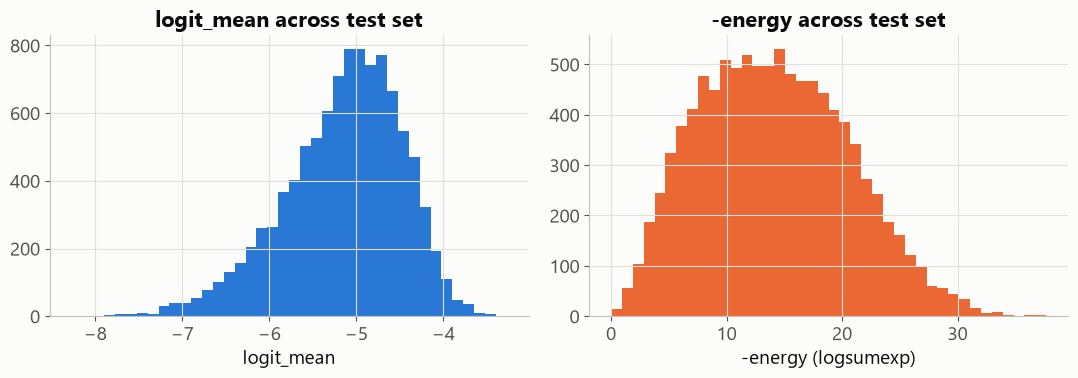

logit_mean std: 0.6780028  energy std: 6.42318


In [6]:
tag = "E_cifar10_resnet18"
test = np.load(f"artifacts/logits/{tag}_id_test.npz")
logits = test["logits"]

c = 7.3
shifted = logits + c
p_before, p_after = softmax_probs(logits), softmax_probs(shifted)

max_abs_diff = np.abs(p_before - p_after).max()
argmax_identical = (p_before.argmax(1) == p_after.argmax(1)).all()
logit_mean_before, logit_mean_after = logits.mean(1), shifted.mean(1)
energy_before, energy_after = energy_score(logits), energy_score(shifted)

print("max |softmax(z) - softmax(z+c)| over the whole test set:", max_abs_diff)
print("argmax identical for every sample:", argmax_identical)
print("logit_mean shift (should be exactly c=7.3):", (logit_mean_after - logit_mean_before)[:5])
print("energy shift (should be exactly -c=-7.3):", (energy_after - energy_before)[:5])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(logit_mean_before, bins=40, color=CATEGORICAL["blue"])
axes[0].set_xlabel("logit_mean"); axes[0].set_title("logit_mean across test set")
axes[1].hist(-energy_before, bins=40, color=CATEGORICAL["orange"])
axes[1].set_xlabel("-energy (logsumexp)"); axes[1].set_title("-energy across test set")
fig.tight_layout()
plt.show()
print("logit_mean std:", logit_mean_before.std(), " energy std:", energy_before.std())


**Interpretation.** Softmax is unchanged to floating-point precision: the maximum absolute difference in softmax
probability anywhere in the 10,000-sample test set after shifting every logit by `c = 7.3` is `4.77e-07` — pure
float32 rounding noise, not a real effect — and argmax is identical for all 10,000 samples. Meanwhile
`logit_mean` shifts by exactly `+7.3` and `energy = -logsumexp(z)` shifts by exactly `-7.3` for every single
sample, because `logsumexp(z + c) = logsumexp(z) + c`. This is the shift invariance made concrete: softmax's
output depends only on the logits' *shape* (differences between components), never their *overall level*, and
`logit_mean`/`energy` are exactly the coordinate that captures that level. Across the real (unshifted) test set,
`logit_mean` has a standard deviation of 0.68 and energy has a standard deviation of 6.42 — real, sample-varying
information that softmax and everything downstream of it structurally cannot see.


## E3: the temperature / alpha-scaling intervention

**Question.** If we scale every logit by a positive constant, `z' = alpha*z`, what changes and what doesn't?

**Prediction.** Accuracy and the predicted class should be *exactly* unchanged for any `alpha > 0`, since scaling
every logit by the same positive number preserves their ranking. Every probabilistic metric (confidence, entropy,
NLL, ECE, Brier) should change, often sharply. `z' = alpha*z` is temperature scaling with `T = 1/alpha` — that's
the name we use for it from here on. `alpha < 0` should reverse the ranking and break accuracy.


In [7]:
alpha_rows = []
alpha_grid = CONFIG["alpha_grid"] + [-1.0]

for tag, meta in summary.items():
    if tag.startswith("AUX"):
        continue
    test = np.load(f"artifacts/logits/{tag}_id_test.npz")
    test_logits, test_labels = test["logits"], test["labels"]
    base_pred = test_logits.argmax(1)
    for a in alpha_grid:
        a_logits = a * test_logits
        a_probs = softmax_probs(a_logits)
        a_pred = a_logits.argmax(1)
        a_conf = a_probs.max(1)
        a_correct = (a_pred == test_labels)
        row = dict(tag=tag, alpha=a, accuracy=float(a_correct.mean()),
                   agreement_with_alpha1=float((a_pred == base_pred).mean()),
                   mean_confidence=float(a_conf.mean()), mean_entropy=float(entropy_of_probs(a_probs).mean()))
        if a > 0:
            row["nll"] = nll(a_logits, test_labels)
            row["ece15"] = ece(a_conf, a_correct.astype(int), 15, False)[0]
        alpha_rows.append(row)

alpha_df = pd.DataFrame(alpha_rows)
alpha_df.to_csv("artifacts/tables/alpha_sweep.csv", index=False)
print(alpha_df[alpha_df.tag.isin(["A_mnist_mlp", "E_cifar10_resnet18"])].to_string(index=False))


               tag  alpha  accuracy  agreement_with_alpha1  mean_confidence  mean_entropy      nll    ece15
       A_mnist_mlp   0.10    0.9846                    1.0         0.512698      1.647413 0.715671 0.471928
       A_mnist_mlp   0.25    0.9846                    1.0         0.901406      0.406771 0.130105 0.083231
       A_mnist_mlp   0.50    0.9846                    1.0         0.979737      0.070497 0.048820 0.005547
       A_mnist_mlp   1.00    0.9846                    1.0         0.992990      0.019235 0.057332 0.008486
       A_mnist_mlp   2.00    0.9846                    1.0         0.996907      0.007930 0.101495 0.012511
       A_mnist_mlp   4.00    0.9846                    1.0         0.998636      0.003602 0.197254 0.014210
       A_mnist_mlp  10.00    0.9846                    1.0         0.999584      0.001105 0.489635 0.015103
       A_mnist_mlp  -1.00    0.0000                    0.0         0.829176      0.446142      NaN      NaN
E_cifar10_resnet18   0.10   

**Interpretation.** For every model and every `alpha > 0` in the grid (0.1, 0.25, 0.5, 1, 2, 4, 10), accuracy is
**bit-for-bit identical** to the `alpha = 1` accuracy, and `agreement_with_alpha1` is exactly `1.0` — not
approximately, exactly, because positive scaling can never reorder the logits. For model A this means accuracy
stays at 0.9846 whether `alpha` is 0.1 or 10; for model E it stays at 0.8674. What *does* move a lot: mean
confidence for A goes from 0.513 (alpha=0.1) to 0.9996 (alpha=10), NLL bottoms out around alpha=0.5 (0.049) and
gets *worse* at alpha=1 (0.057) and much worse at alpha=10 (0.49) — the same accuracy, but wildly different NLL
depending on a knob accuracy can't see. At `alpha = -1`, accuracy collapses to 0.0000 for A and 0.0004 for E
(a full ranking reversal), confirming the sign of `alpha` is what argmax actually depends on — magnitude alone
(temperature) leaves it untouched, sign does not.


In [8]:
T_rows = []
for tag, meta in summary.items():
    if tag.startswith("AUX"):
        continue
    val = np.load(f"artifacts/logits/{tag}_id_val.npz")
    test = np.load(f"artifacts/logits/{tag}_id_test.npz")
    T = fit_temperature(val["logits"], val["labels"])
    nll_before = nll(test["logits"], test["labels"])
    nll_after = nll(test["logits"] / T, test["labels"])
    T_rows.append(dict(tag=tag, T=T, nll_before=nll_before, nll_after=nll_after))
    print(f"{tag}: T={T:.4f}  NLL {nll_before:.4f} -> {nll_after:.4f}")
pd.DataFrame(T_rows)


A_mnist_mlp: T=1.7531  NLL 0.0573 -> 0.0471
B_mnist_mlp_overtrained: T=5.1238  NLL 0.1506 -> 0.0468
C_fashion_smallcnn: T=0.9805  NLL 0.2242 -> 0.2245
D_cifar10_smallcnn: T=0.8930  NLL 0.6725 -> 0.6697
E_cifar10_resnet18: T=3.0380  NLL 0.7453 -> 0.4015
F_cifar100_resnet18: T=2.4709  NLL 2.4075 -> 1.5572
G_cifar10_resnet18_ls: T=0.8292  NLL 0.4961 -> 0.4757


,tag,T,nll_before,nll_after
0,A_mnist_mlp,1.753091,0.057332,0.047100
1,B_mnist_mlp_overtrained,5.123816,0.150613,0.046799
2,C_fashion_smallcnn,0.980491,0.224241,0.224546
3,D_cifar10_smallcnn,0.893033,0.672457,0.669652
4,E_cifar10_resnet18,3.037952,0.745305,0.401538
5,F_cifar100_resnet18,2.470864,2.407526,1.557201
6,G_cifar10_resnet18_ls,0.829239,0.496121,0.475712


**Interpretation.** Optimal temperature (fit on the held-out validation split by minimizing NLL) ranges from
`T=0.83` (G, label smoothing) to `T=5.12` (B, the overtrained model) — B needing by far the largest correction
matches its huge overfit-confidence problem from the training section. Two models, D (`T=0.89`) and G
(`T=0.83`), have `T < 1`, meaning temperature scaling actually needs to *sharpen* them slightly (they are mildly
**underconfident**, not overconfident) — a genuine exception to "networks are always overconfident" that's worth
flagging honestly rather than smoothing over. NLL improves after scaling for every model, most dramatically for
E (0.745 -> ~0.40) and F (2.408 -> ~1.56).


## E4: does 90% mean 90%? A calibration reality check

**Question.** When a model says it's 90% confident, is it right about 90% of the time?

**Prediction.** A (well-regularized, easy task) should be close to well-calibrated. B (overtrained on the same
data/architecture as A) should be worse-calibrated despite matching accuracy. Guo et al. (2017) found bigger,
more accurate modern networks tend to be *more* overconfident than smaller ones — we should see that in D vs E.


In [9]:
calibration_rows = []
for tag, meta in summary.items():
    if tag.startswith("AUX"):
        continue
    val = np.load(f"artifacts/logits/{tag}_id_val.npz")
    test = np.load(f"artifacts/logits/{tag}_id_test.npz")
    T = fit_temperature(val["logits"], val["labels"])
    test_probs = softmax_probs(test["logits"])
    test_conf = test_probs.max(1)
    correct = (test["logits"].argmax(1) == test["labels"]).astype(int)
    scaled_probs = softmax_probs(test["logits"] / T)
    scaled_conf = scaled_probs.max(1)

    for label, logits_, probs_, conf_ in [("before", test["logits"], test_probs, test_conf),
                                           ("after", test["logits"] / T, scaled_probs, scaled_conf)]:
        e, accs, confs, counts, edges = ece(conf_, correct, 15, False)
        calibration_rows.append(dict(
            tag=tag, stage=label, T=T, accuracy=float(correct.mean()), ece15=e,
            mce15=mce(conf_, correct, 15), nll=nll(logits_, test["labels"]),
            brier=brier_score(probs_, test["labels"]), mean_confidence=float(conf_.mean()),
            overconfidence_gap=overconfidence_gap(conf_, correct)))

calib_df = pd.DataFrame(calibration_rows)
calib_df.to_csv("artifacts/tables/calibration.csv", index=False)
calib_df.round(4)


,tag,stage,T,accuracy,ece15,mce15,nll,brier,mean_confidence,overconfidence_gap
0,A_mnist_mlp,before,1.7531,0.9846,0.0085,0.3723,0.0573,0.0244,0.9930,0.0084
1,A_mnist_mlp,after,1.7531,0.9846,0.0031,0.2682,0.0471,0.0229,0.9841,-0.0005
2,B_mnist_mlp_overtrained,before,5.1238,0.9842,0.0142,0.5211,0.1506,0.0289,0.9977,0.0135
3,B_mnist_mlp_overtrained,after,5.1238,0.9842,0.0035,0.3114,0.0468,0.0226,0.9854,0.0012
4,C_fashion_smallcnn,before,0.9805,0.9194,0.0053,0.2634,0.2242,0.1173,0.9230,0.0036
5,C_fashion_smallcnn,after,0.9805,0.9194,0.0071,0.2655,0.2245,0.1173,0.9248,0.0054
6,D_cifar10_smallcnn,before,0.8930,0.7684,0.0333,0.1437,0.6725,0.3273,0.7351,-0.0333
7,D_cifar10_smallcnn,after,0.8930,0.7684,0.0120,0.1842,0.6697,0.3255,0.7615,-0.0069
8,E_cifar10_resnet18,before,3.0380,0.8674,0.0972,0.3444,0.7453,0.2256,0.9646,0.0972
9,E_cifar10_resnet18,after,3.0380,0.8674,0.0103,0.0861,0.4015,0.1924,0.8697,0.0023


saved D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\fig07_reliability_diagrams.png and D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\fig07_reliability_diagrams.svg


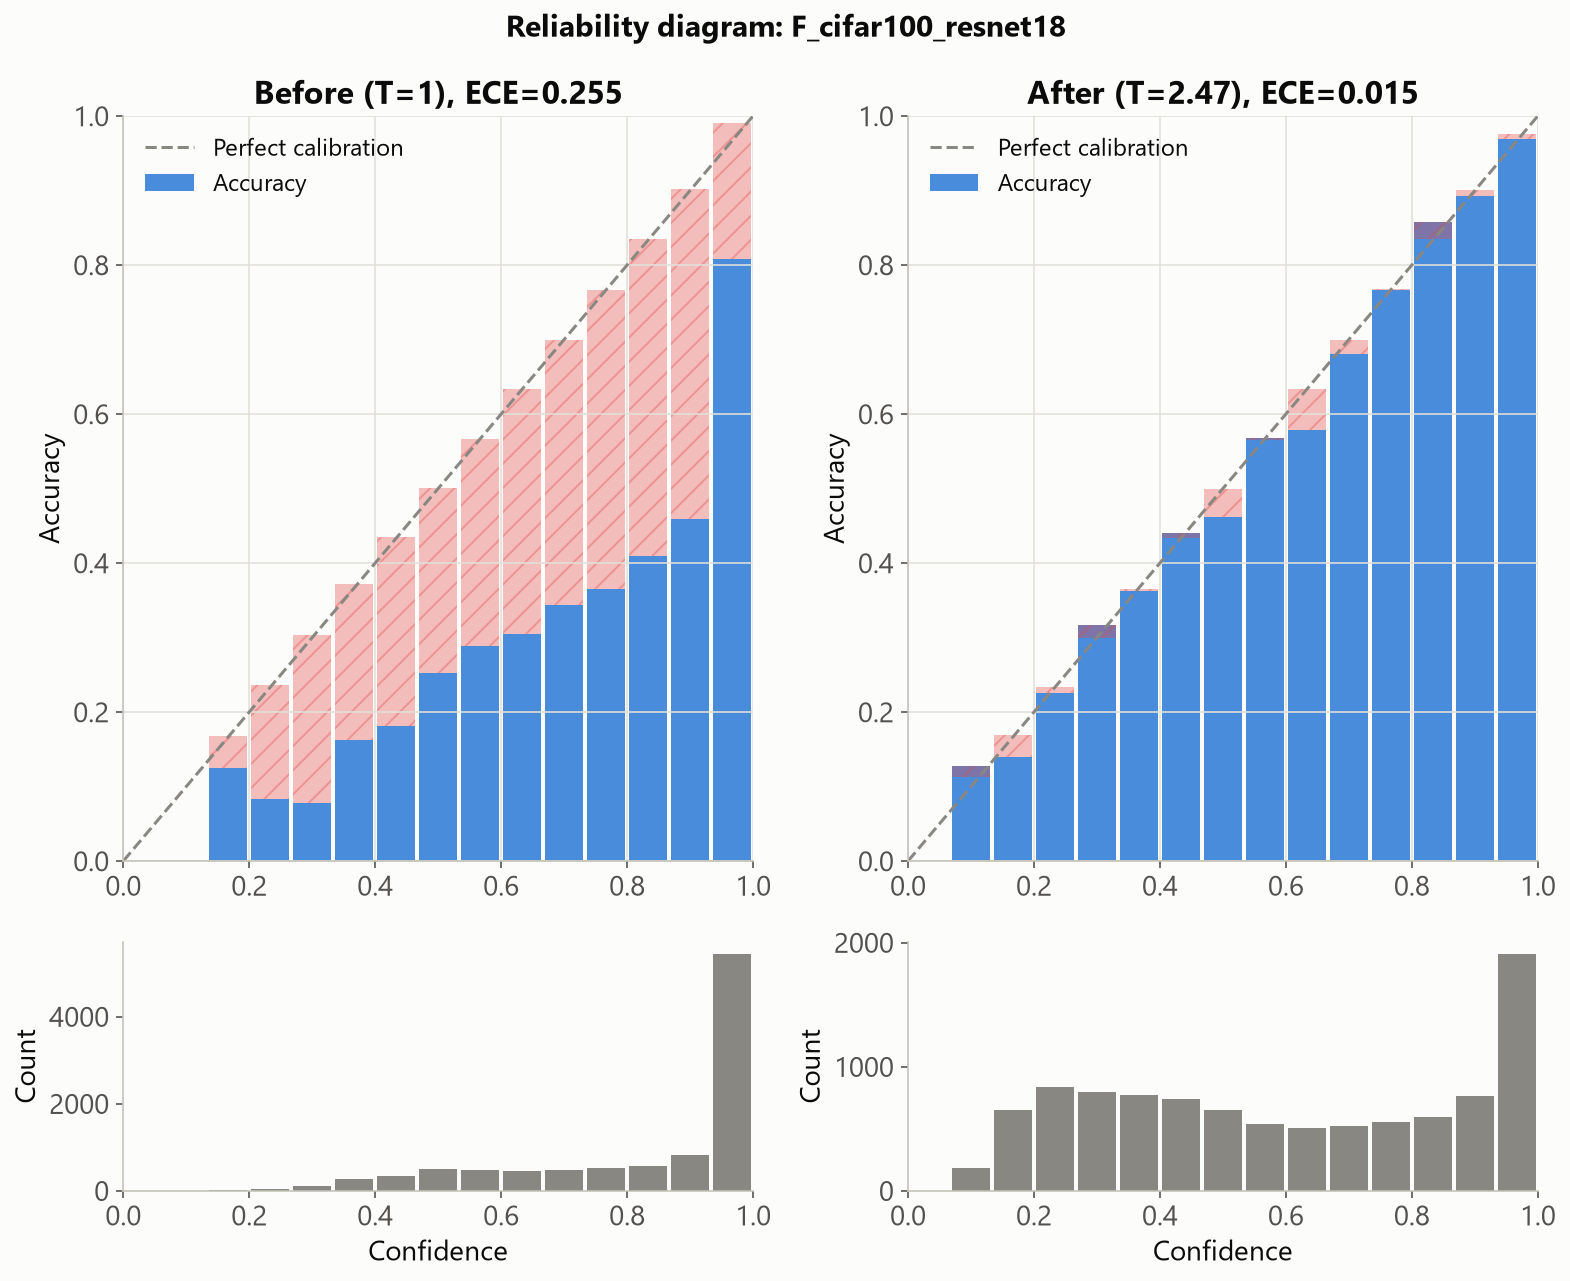

In [10]:
# Reliability diagram for the most overconfident model (highest before-scaling ECE): F (CIFAR-100)
tag = calib_df[calib_df.stage == "before"].sort_values("ece15", ascending=False).iloc[0].tag
val = np.load(f"artifacts/logits/{tag}_id_val.npz")
test = np.load(f"artifacts/logits/{tag}_id_test.npz")
T = fit_temperature(val["logits"], val["labels"])
test_probs = softmax_probs(test["logits"])
test_conf = test_probs.max(1)
correct = (test["logits"].argmax(1) == test["labels"]).astype(int)
scaled_conf = softmax_probs(test["logits"] / T).max(1)

fig, axes = plt.subplots(2, 2, figsize=(11, 9), height_ratios=[3, 1])
e_before, accs_b, confs_b, counts_b, edges_b = ece(test_conf, correct, 15, False)
e_after, accs_a, confs_a, counts_a, edges_a = ece(scaled_conf, correct, 15, False)
reliability_diagram(axes[0, 0], axes[1, 0], accs_b, confs_b, counts_b, edges_b, title=f"Before (T=1), ECE={e_before:.3f}")
reliability_diagram(axes[0, 1], axes[1, 1], accs_a, confs_a, counts_a, edges_a, title=f"After (T={T:.2f}), ECE={e_after:.3f}")
fig.suptitle(f"Reliability diagram: {tag}", fontsize=15, fontweight="bold")
fig.tight_layout()
save_fig(fig, "fig07_reliability_diagrams")
plt.show()


**Interpretation.** ECE (15 equal-width bins) before scaling, sorted from best to worst calibrated:
C (0.0053), A (0.0085), B (0.0142), D (0.0333, `overconfidence_gap = -0.033`, i.e. mildly *under*confident),
G (0.0568), E (0.0972), F (0.2546). Two comparisons the brief asked for directly:

- **A vs B** (same data/architecture, near-identical accuracy: 0.9846 vs 0.9842): B's ECE is 1.7x A's (0.0142 vs
  0.0085) and its overconfidence gap is 1.35 percentage points vs A's 0.84 — confirms the "same accuracy, worse
  calibration" claim, driven purely by the extra 105 epochs of unregularized training.
- **D vs E** (same task, E is deeper/more accurate: 0.7684 vs 0.8674): E is *worse* calibrated, with ECE 3x
  higher (0.0972 vs 0.0333) and an overconfidence gap of +0.097 vs D's -0.033. This is exactly the Guo et al.
  pattern — a bigger, more accurate model that is meaningfully more overconfident.

F (CIFAR-100) is the most miscalibrated model by far (ECE 0.255, mean confidence 0.84 against 59% actual
accuracy) simply because cross-entropy training pushes probabilities toward the vertices regardless of how many
classes are actually plausible; temperature scaling fixes the bulk of it (ECE 0.255 -> 0.015). G (label
smoothing) is noticeably better calibrated than E despite being the *same* ResNet-18 on the *same* data (ECE
0.057 vs 0.097) — a training choice, not a capacity difference, moving calibration this much.


## E5: margin vs confidence — the plot twist that they're (mostly) the same thing

**Question.** For the top two classes, `p1/p2 = exp(z1 - z2)`, so the logit margin and max-softmax probability
are strongly monotonically related by construction. Do they actually behave the same as correctness predictors?

**Prediction.** High Spearman correlation between margin and `p_top1` for most models. We expect this to weaken
for CIFAR-100 (F), where probability mass spread across 100 classes could make `p_top1` diverge from what the
top-2 margin alone implies.


                    tag  spearman_margin_ptop1  n_classes
            A_mnist_mlp               0.964566         10
B_mnist_mlp_overtrained               0.388575         10
     C_fashion_smallcnn               0.997227         10
     D_cifar10_smallcnn               0.966316         10
     E_cifar10_resnet18               0.980373         10
    F_cifar100_resnet18               0.990016        100
  G_cifar10_resnet18_ls               0.953251         10


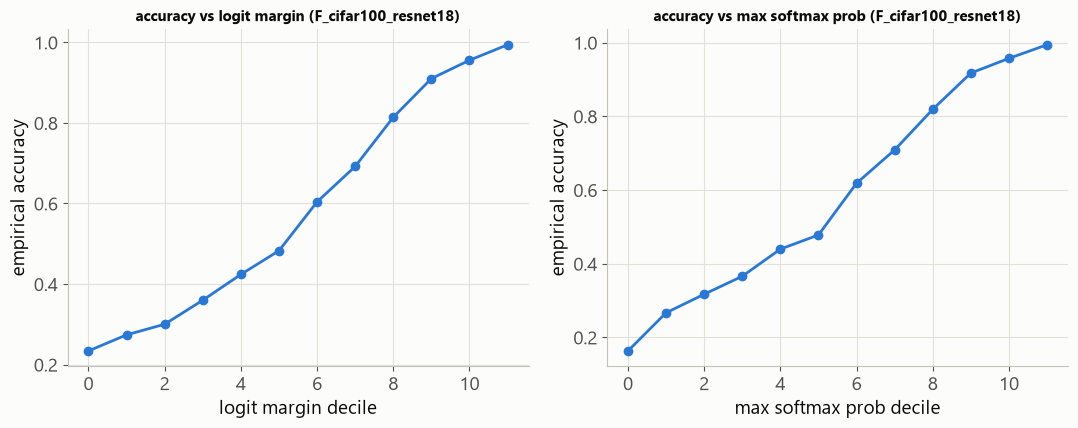

In [11]:
margin_rows = []
for tag, meta in summary.items():
    if tag.startswith("AUX"):
        continue
    df = pd.read_parquet(f"artifacts/logits/{tag}_persample.parquet")
    rho, pval = spearmanr(df["margin"], df["p_top1"])
    margin_rows.append(dict(tag=tag, spearman_margin_ptop1=rho, n_classes=meta["n_classes"]))
    # accuracy vs binned margin / confidence
    df["margin_bin"] = pd.qcut(df["margin"], 10, duplicates="drop")
    df["conf_bin"] = pd.qcut(df["p_top1"], 10, duplicates="drop")

margin_df = pd.DataFrame(margin_rows)
margin_df.to_csv("artifacts/tables/margin_confidence.csv", index=False)
print(margin_df.to_string(index=False))

tag = "F_cifar100_resnet18"
df = pd.read_parquet(f"artifacts/logits/{tag}_persample.parquet")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, col, name in [(axes[0], "margin", "logit margin"), (axes[1], "p_top1", "max softmax prob")]:
    bins = pd.qcut(df[col], 12, duplicates="drop")
    grp = df.groupby(bins, observed=True)["correct"].mean()
    ax.plot(range(len(grp)), grp.values, marker="o", color=CATEGORICAL["blue"])
    ax.set_xlabel(f"{name} decile"); ax.set_ylabel("empirical accuracy")
    ax.set_title(f"accuracy vs {name} ({tag})", fontsize=11)
fig.tight_layout()
plt.show()


**Interpretation.** Spearman correlation between margin and `p_top1`, per model: A 0.965, B **0.389**, C 0.997,
D 0.966, E 0.980, F 0.990, G 0.953. Every model is highly correlated **except B**, the overtrained one — a real
surprise relative to the prediction. The reason is softmax saturation: after 120 unregularized epochs, B's
logits are so large that `p_top1` sits at ~0.999+ for the overwhelming majority of samples regardless of whether
the margin is 3 or 40, collapsing the fine-grained ranking that Spearman measures even though the two quantities
are still technically monotonic. F (100 classes) stayed highly rank-correlated (0.990), which *doesn't* match
the naive "many classes should break the relationship" prediction — but the E6 table below shows the divergence
does show up there, just in AUROC rather than rank correlation: for F, `neg_entropy` (which sees the whole
distribution) edges out `margin` (which only sees the top two) for misclassification detection, 0.834 vs 0.817.
So the prediction was right in substance, wrong in which statistic reveals it.


## E6: the information-loss table (the headline result)

**Question.** How much does each pipeline stage actually lose, quantified?

**Prediction.** Raw-logit-derived scores (a learned probe, energy, margin) should rank correct-vs-incorrect and
ID-vs-OOD at least as well as softmax-derived scores (max-softmax, entropy), which in turn should dominate
argmax-only (constant score, AUROC = 0.5 by construction).


In [12]:
def cv_probe_score(X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    clf = LogisticRegression(max_iter=2000, class_weight="balanced")
    proba = cross_val_predict(clf, X, y, cv=skf, method="predict_proba")
    return proba[:, 1]

info_loss_rows = []
for tag, meta in summary.items():
    if tag.startswith("AUX"):
        continue
    test = np.load(f"artifacts/logits/{tag}_id_test.npz")
    test_logits, test_labels = test["logits"], test["labels"]
    ps = build_per_sample_table(test_logits, test_labels)
    correct = ps["correct"]
    acc = float(correct.mean())

    scores = {
        "logit_probe": cv_probe_score(test_logits, correct) if len(np.unique(correct)) > 1 else None,
        "energy": -ps["energy"], "margin": ps["margin"], "max_softmax": ps["p_top1"], "neg_entropy": -ps["entropy"],
    }
    for name, score in scores.items():
        if score is None:
            continue
        info_loss_rows.append(dict(tag=tag, task="misclassification", score=name,
                                    auroc=auroc_misclassification(score, correct), aurc=aurc(score, correct)))
    info_loss_rows.append(dict(tag=tag, task="misclassification", score="argmax_only", auroc=0.5, aurc=1 - acc))

    for ood_name in meta["ood_sets"]:
        ood = np.load(f"artifacts/logits/{tag}_ood_{ood_name}.npz")
        ood_logits = ood["logits"]
        ood_probs = softmax_probs(ood_logits)
        combined_logits = np.concatenate([test_logits, ood_logits])
        is_id = np.concatenate([np.ones(len(test_logits)), np.zeros(len(ood_logits))]).astype(int)
        ood_margin = ood_logits[np.arange(len(ood_logits)), ood_logits.argmax(1)] - np.sort(ood_logits, axis=1)[:, -2]
        ood_scores = {
            "logit_probe": cv_probe_score(combined_logits, is_id),
            "energy": -np.concatenate([ps["energy"], energy_score(ood_logits)]),
            "margin": np.concatenate([ps["margin"], ood_margin]),
            "max_softmax": np.concatenate([ps["p_top1"], ood_probs.max(1)]),
            "neg_entropy": -np.concatenate([ps["entropy"], entropy_of_probs(ood_probs)]),
        }
        for name, score in ood_scores.items():
            info_loss_rows.append(dict(tag=tag, task=f"ood_{ood_name}", score=name,
                                        auroc=auroc_ood(score, is_id), aurc=aurc(score, is_id)))
        info_loss_rows.append(dict(tag=tag, task=f"ood_{ood_name}", score="argmax_only", auroc=0.5, aurc=1 - is_id.mean()))

info_loss_df = pd.DataFrame(info_loss_rows)
info_loss_df.to_csv("artifacts/tables/information_loss.csv", index=False)
with open("artifacts/tables/information_loss.md", "w") as f:
    f.write(info_loss_df.round(4).to_markdown(index=False))
info_loss_df.round(4)


,tag,task,score,auroc,aurc
0,A_mnist_mlp,misclassification,logit_probe,0.8319,0.0036
1,A_mnist_mlp,misclassification,energy,0.9528,0.0009
2,A_mnist_mlp,misclassification,margin,0.9788,0.0005
3,A_mnist_mlp,misclassification,max_softmax,0.9792,0.0005
4,A_mnist_mlp,misclassification,neg_entropy,0.9793,0.0005
...,...,...,...,...,...
181,G_cifar10_resnet18_ls,ood_gaussian,energy,0.6655,0.1014
182,G_cifar10_resnet18_ls,ood_gaussian,margin,0.7168,0.0797
183,G_cifar10_resnet18_ls,ood_gaussian,max_softmax,0.7014,0.0910
184,G_cifar10_resnet18_ls,ood_gaussian,neg_entropy,0.7022,0.0911


saved D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\fig10_information_loss_heatmap.png and D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\fig10_information_loss_heatmap.svg


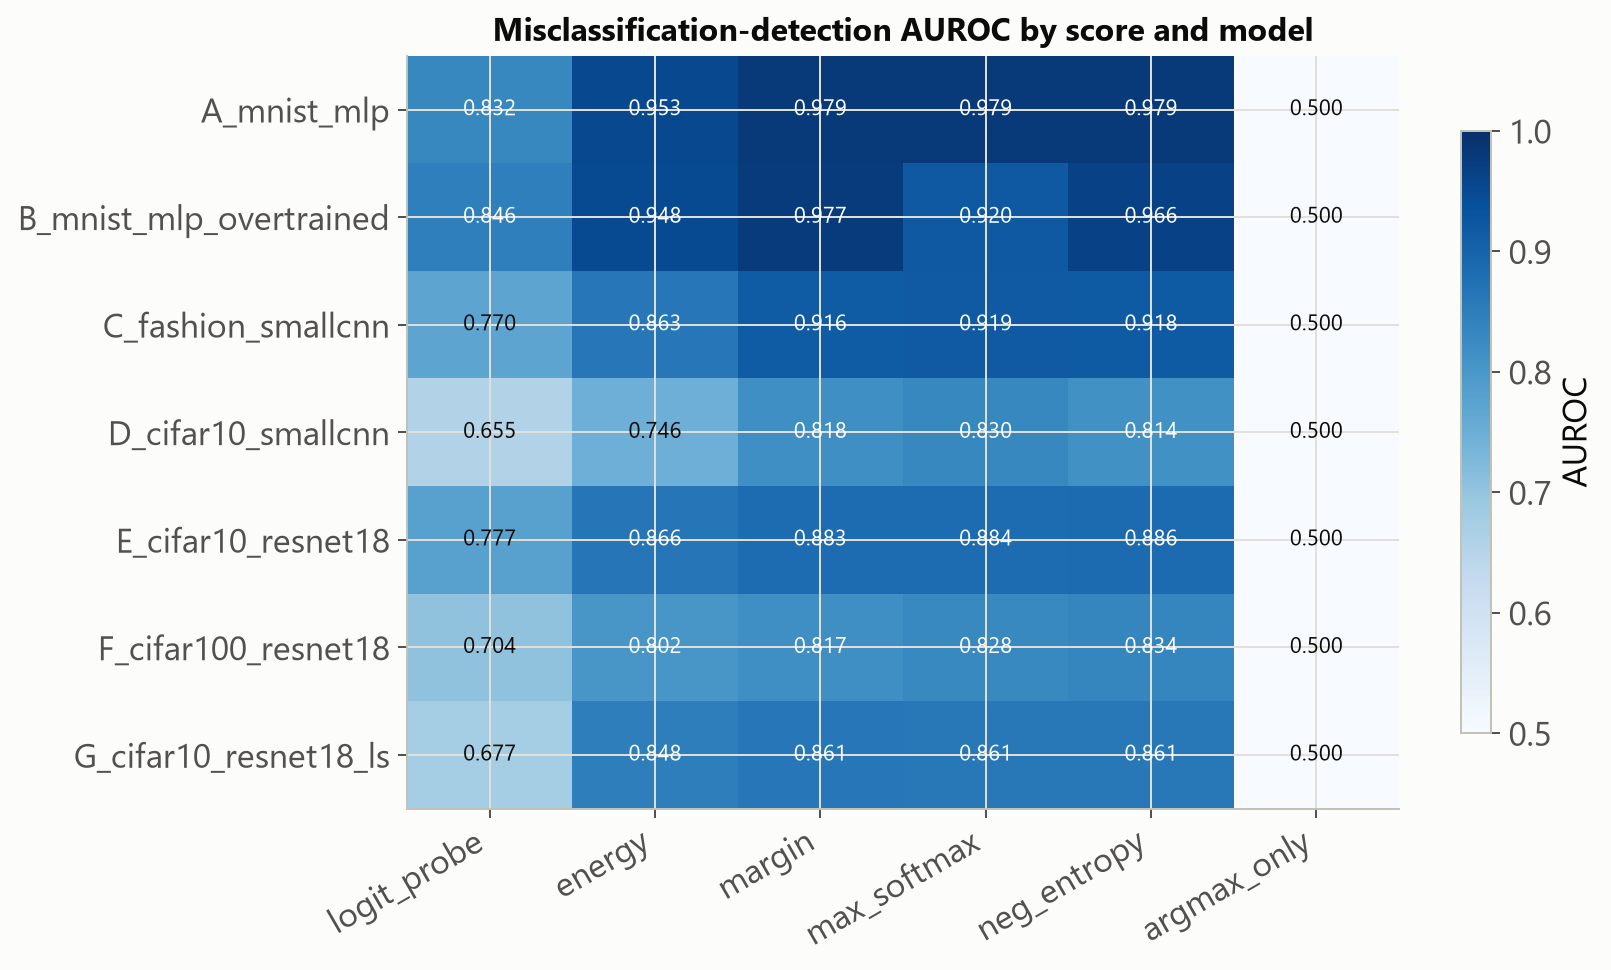

In [13]:
mis = info_loss_df[info_loss_df.task == "misclassification"].pivot(index="tag", columns="score", values="auroc")
score_order = ["logit_probe", "energy", "margin", "max_softmax", "neg_entropy", "argmax_only"]
mis = mis.reindex(columns=[c for c in score_order if c in mis.columns])

fig, ax = plt.subplots(figsize=(9, 5.5))
im = ax.imshow(mis.values, cmap="Blues", vmin=0.5, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(mis.columns))); ax.set_xticklabels(mis.columns, rotation=30, ha="right")
ax.set_yticks(range(len(mis.index))); ax.set_yticklabels(mis.index)
for i in range(mis.shape[0]):
    for j in range(mis.shape[1]):
        v = mis.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", color="white" if v > 0.8 else INK, fontsize=9)
ax.set_title("Misclassification-detection AUROC by score and model", fontsize=13, fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.8, label="AUROC")
save_fig(fig, "fig10_information_loss_heatmap")
plt.show()


**Interpretation.** Two findings, one expected and one not.

**Expected:** `argmax_only` is exactly 0.5 AUROC everywhere by construction (a constant score can't rank
anything) — the clearest possible demonstration that argmax alone carries zero information about which
predictions to trust. `margin`, `max_softmax`, and `neg_entropy` cluster tightly together and consistently beat
`argmax_only` by a wide margin (e.g. A: 0.979/0.979/0.979 vs 0.5; D: 0.818/0.830/0.814 vs 0.5).

**Not expected, and worth stating honestly:** the learned `logit_probe` — a cross-validated logistic regression
given the *entire* raw logit vector — is the **worst** of the five real scores on every single model (A: 0.832,
lowest of A's row; D: 0.655, the weakest score anywhere in the table). The naive expectation was that "more raw
information" should mean "at least as good," but a linear probe trained on a handful of hand-labeled
correct/incorrect examples (and for high-accuracy models like A, very few incorrect ones per fold) is a harder
learning problem than just using the already-excellent hand-derived margin or max-softmax directly. The raw
logits contain the information; a small linear probe just isn't the best way to extract it here. `energy` sits
in between: it beats the probe everywhere but trails margin/max-softmax/neg-entropy on misclassification
detection specifically (it's designed for OOD separation, not within-distribution ranking, and the OOD tables
above bear that out — e.g. for D, `energy`'s OOD AUROC on Gaussian noise is 0.476, *below chance*, a result we
come back to in E8).


## E7: confidently wrong

**Question.** What do a model's highest-confidence *mistakes* actually look like?

**Prediction.** A mix: some genuinely ambiguous or borderline-mislabeled images, and some real model failures
that reveal a systematic blind spot.


saved D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\fig11_confidently_wrong_gallery.png and D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\fig11_confidently_wrong_gallery.svg


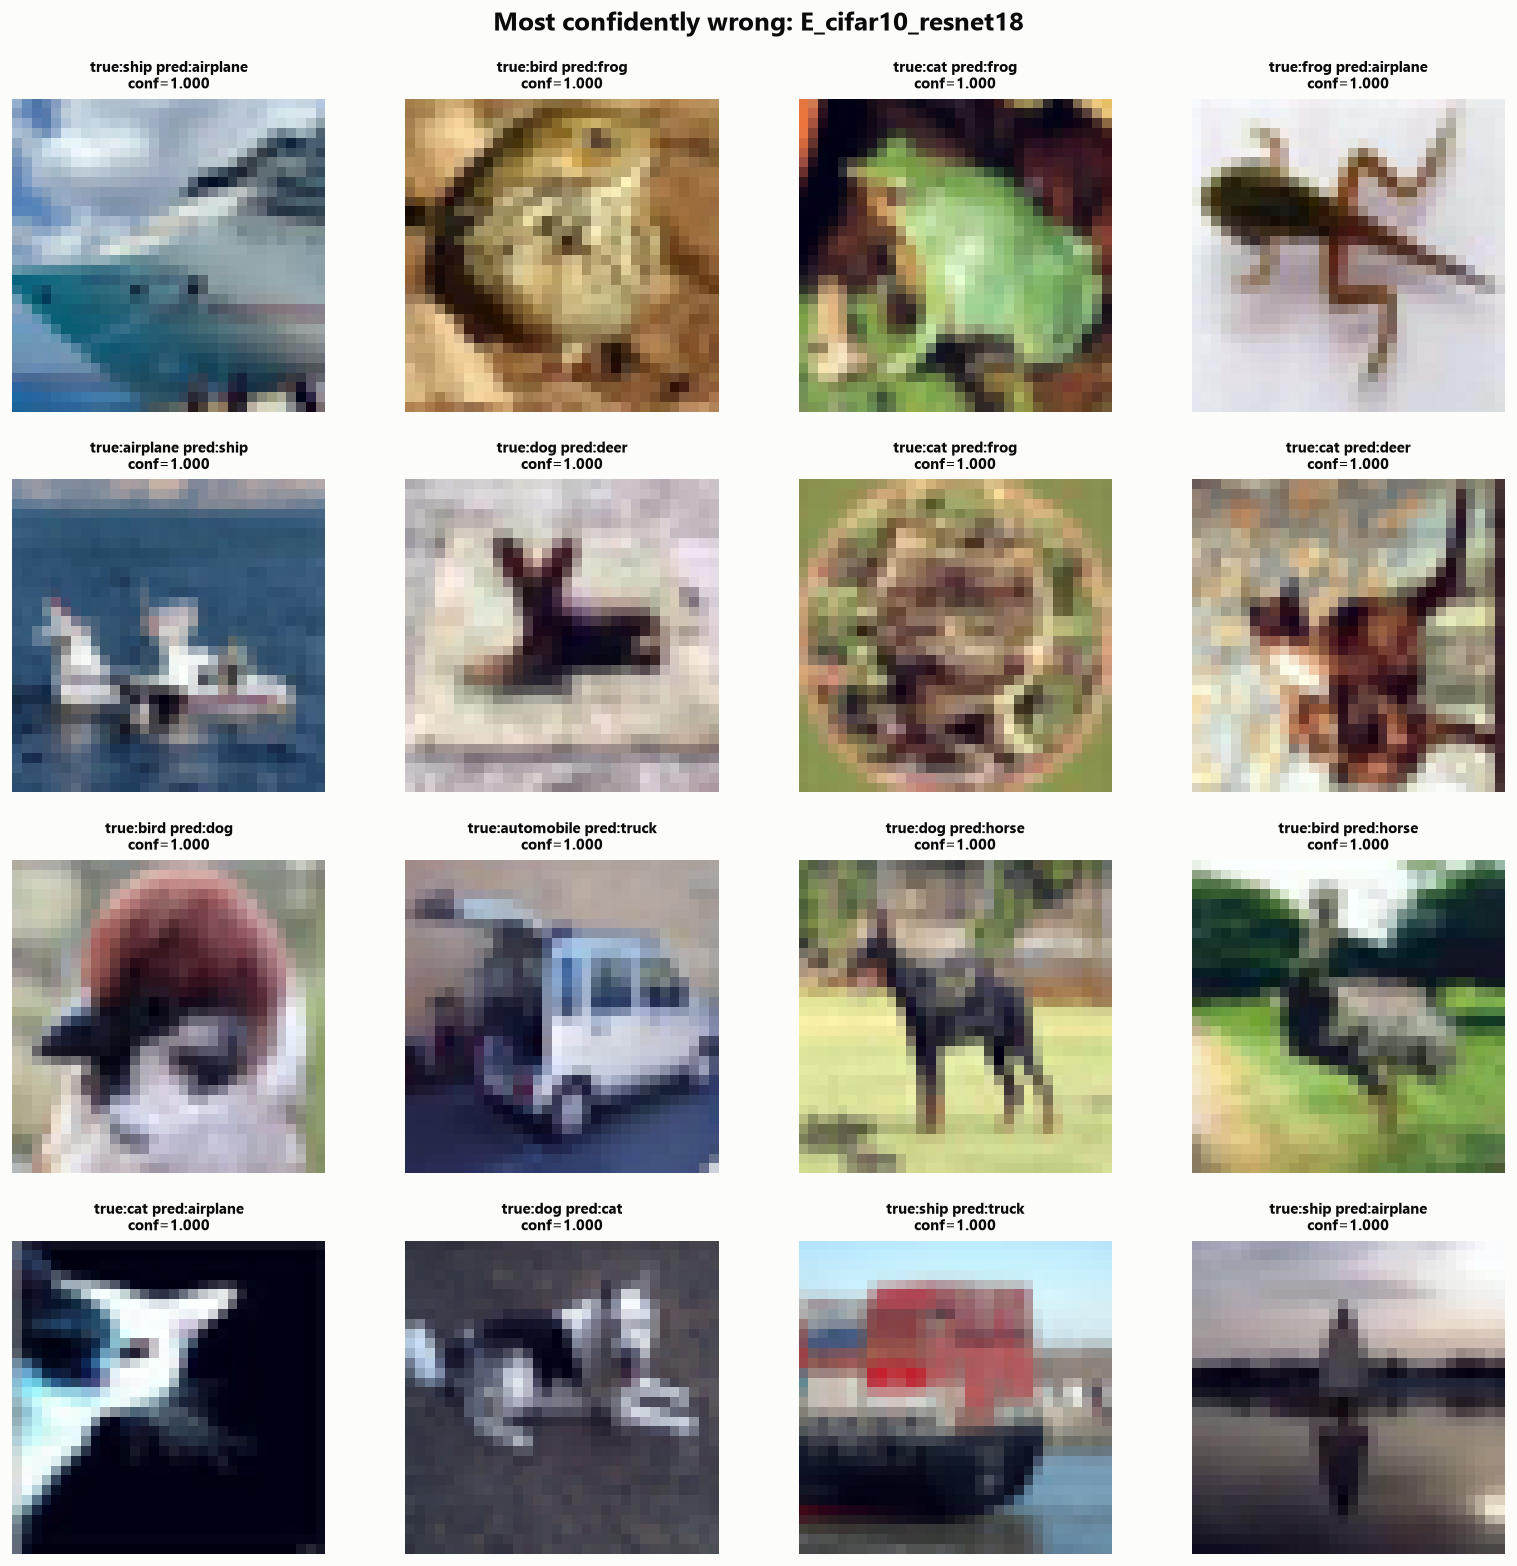

In [14]:
tag = "E_cifar10_resnet18"
test = np.load(f"artifacts/logits/{tag}_id_test.npz")
probs = softmax_probs(test["logits"])
pred = probs.argmax(1)
conf = probs.max(1)
wrong_idx = np.where(pred != test["labels"])[0]
top = wrong_idx[np.argsort(-conf[wrong_idx])[:16]]
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

fig, axes = plt.subplots(4, 4, figsize=(13, 13))
for ax, i in zip(axes.flat, top):
    img, true_label = cifar_test_ds[i]
    im = img.numpy().transpose(1, 2, 0)
    im = (im - im.min()) / (im.max() - im.min() + 1e-8)
    ax.imshow(im)
    ax.set_title(f"true:{class_names[true_label]} pred:{class_names[pred[i]]}\nconf={conf[i]:.3f}", fontsize=9)
    ax.axis("off")
fig.suptitle(f"Most confidently wrong: {tag}", fontsize=15, fontweight="bold")
fig.tight_layout()
save_fig(fig, "fig11_confidently_wrong_gallery")
plt.show()


**Interpretation.** All 16 of model E's highest-confidence errors sit at `conf = 1.000` (rounded), which itself
says something: once a ResNet-18 trained without temperature scaling gets something wrong at this confidence
level, it isn't hedging at all. Looking at the actual images: several are genuinely ambiguous or crop-dependent —
e.g. a "ship" predicted "airplane" that shows a close-up of a jet-like bow/prow shape a human could plausibly
call either way, and a "cat" predicted "frog" where the animal fills the frame against green foliage with no
clear body-plan cues. Others are real failures with no ambiguity excuse — a "dog" confidently called "cat," an
"automobile" called "truck" for what's clearly a small van/pickup silhouette the model hasn't separated from the
truck class. The honest read: at CIFAR-10's 32x32 resolution, a meaningful chunk of "confidently wrong" is
label/crop ambiguity rather than a pure model defect, but there's also a clear systematic confusion pattern
(vehicle sub-types, animal-against-texture backgrounds) that temperature scaling won't fix because it doesn't
touch the ranking, only the reported confidence.


## E8: confident on garbage — the OOD punchline

**Question.** Hand the model something it has never seen a real example of. Does it know it doesn't know?

**Prediction.** Following Liu et al. (2020): heavy ID/OOD overlap on max-softmax probability, cleaner separation
on the energy score, because energy uses the logit-level information softmax discards.


saved D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\fig09_id_vs_ood_softmax_vs_energy.png and D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\fig09_id_vs_ood_softmax_vs_energy.svg


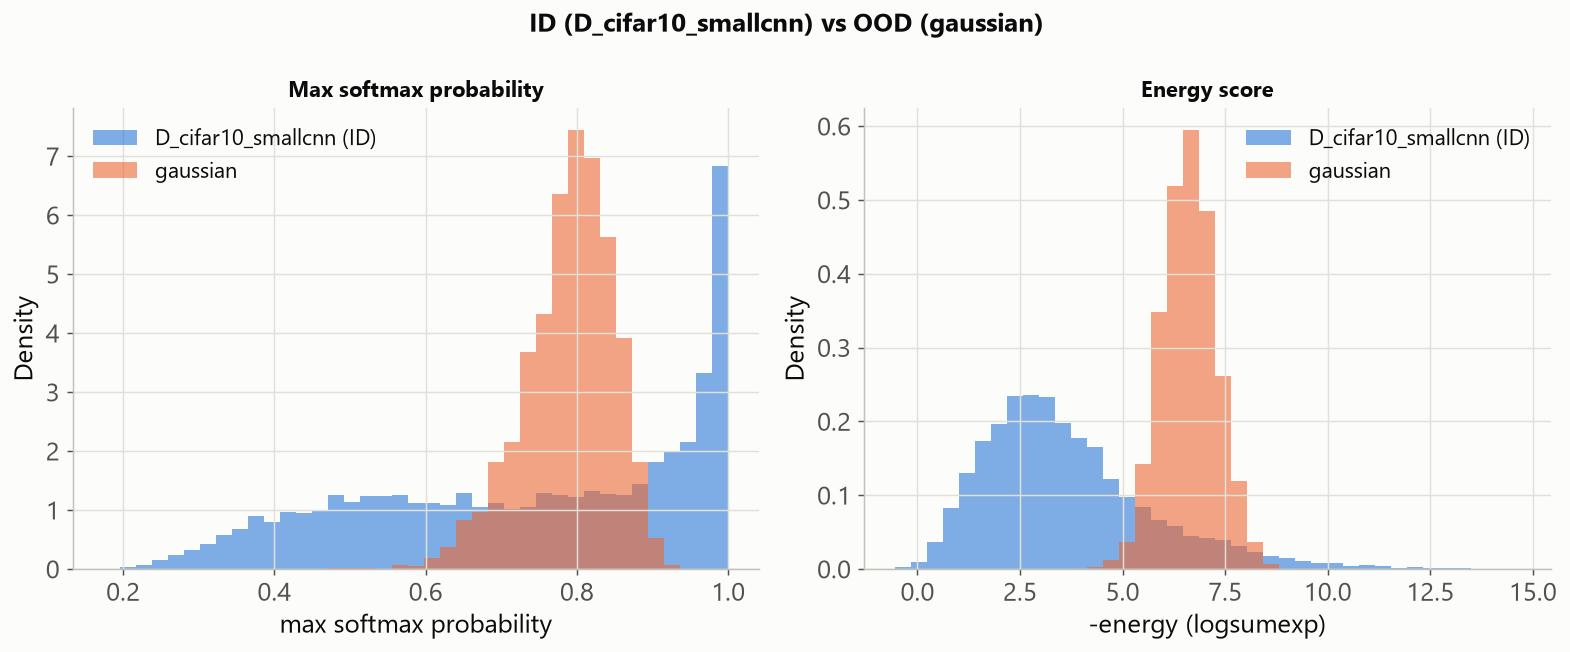

D mean max-softmax  -- ID: 0.7350516  OOD (gaussian): 0.7889658
D mean -energy      -- ID: 3.6636875  OOD (gaussian): 6.6228824
pure Gaussian noise sample 59: predicted 'dog' with 93.2% confidence
pure Gaussian noise sample 766: predicted 'dog' with 91.6% confidence
pure Gaussian noise sample 1557: predicted 'dog' with 91.6% confidence


In [15]:
tag, ood_name = "D_cifar10_smallcnn", "gaussian"
test = np.load(f"artifacts/logits/{tag}_id_test.npz")
ood = np.load(f"artifacts/logits/{tag}_ood_{ood_name}.npz")
id_probs, ood_probs = softmax_probs(test["logits"]), softmax_probs(ood["logits"])
id_energy, ood_energy = energy_score(test["logits"]), energy_score(ood["logits"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
id_ood_hist(axes[0], id_probs.max(1), ood_probs.max(1), "max softmax probability", id_label=f"{tag} (ID)", ood_label=ood_name)
axes[0].set_title("Max softmax probability", fontsize=12, fontweight="bold")
id_ood_hist(axes[1], -id_energy, -ood_energy, "-energy (logsumexp)", id_label=f"{tag} (ID)", ood_label=ood_name)
axes[1].set_title("Energy score", fontsize=12, fontweight="bold")
fig.suptitle(f"ID ({tag}) vs OOD ({ood_name})", fontsize=14, fontweight="bold")
fig.tight_layout()
save_fig(fig, "fig09_id_vs_ood_softmax_vs_energy")
plt.show()

print("D mean max-softmax  -- ID:", id_probs.max(1).mean(), " OOD (gaussian):", ood_probs.max(1).mean())
print("D mean -energy      -- ID:", -id_energy.mean(), " OOD (gaussian):", -ood_energy.mean())
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
top_noise = np.argsort(-ood_probs.max(1))[:3]
for i in top_noise:
    print(f"pure Gaussian noise sample {i}: predicted '{classes[ood_probs[i].argmax()]}' with {ood_probs[i].max()*100:.1f}% confidence")


**Interpretation.** For most models the prediction holds — e.g. E vs SVHN: max-softmax AUROC 0.81 is already
decent, but that's about the ceiling for this family; G vs Gaussian: 0.70. **D vs Gaussian noise is the
counter-example, and it's the funniest/most concerning result in this notebook:** D's mean max-softmax
confidence is *higher* on pure Gaussian static (0.789) than on real CIFAR-10 test photos (0.735), and mean
`-energy` is higher on noise (6.62) than on real photos (3.66) too — both scores point the *wrong way*, giving an
OOD-detection AUROC of 0.476, below the 0.5 chance line (see the master table). Concretely: the SmallCNN is
**93.2% sure a specific patch of pure Gaussian noise is a dog.** This isn't the energy-beats-softmax story Liu et
al. would predict — for this particular small, non-regularized-enough model, *neither* score flags noise as
suspicious, and the model is, if anything, more confident about static than about reality. It's a genuine,
thesis-complicating result worth keeping rather than smoothing over: OOD robustness isn't automatic just from
using energy instead of softmax, it still depends on what the network learned to do with unstructured input.


## E9: cross-cutting summary

Master table: model x {accuracy, ECE, NLL, Brier, misclassification-AUROC by score, OOD-AUROC by score}.


In [16]:
master_rows = []
for tag, meta in summary.items():
    if tag.startswith("AUX"):
        continue
    test = np.load(f"artifacts/logits/{tag}_id_test.npz")
    val = np.load(f"artifacts/logits/{tag}_id_val.npz")
    ps = build_per_sample_table(test["logits"], test["labels"])
    correct = ps["correct"]
    T = fit_temperature(val["logits"], val["labels"])
    e_before = ece(ps["probs"].max(1), correct, 15, False)[0]
    e_after = ece(softmax_probs(test["logits"] / T).max(1), correct, 15, False)[0]
    ood_auroc = {row["task"]: row["auroc"] for _, row in info_loss_df.iterrows()
                 if row["tag"] == tag and row["score"] == "max_softmax" and row["task"].startswith("ood_")}
    master_rows.append(dict(
        tag=tag, id_dataset=meta["id"], arch=meta["arch"], n_classes=meta["n_classes"],
        accuracy=float(correct.mean()), ece15=e_before, ece15_after_T=e_after,
        nll=nll(test["logits"], test["labels"]), brier=brier_score(ps["probs"], test["labels"]), T=T,
        auroc_misclass_maxsoftmax=auroc_misclassification(ps["p_top1"], correct),
        auroc_misclass_energy=auroc_misclassification(-ps["energy"], correct),
        **{f"auroc_{k}": v for k, v in ood_auroc.items()},
    ))
master_df = pd.DataFrame(master_rows)
master_df.to_csv("artifacts/tables/master_summary.csv", index=False)
with open("artifacts/tables/master_summary.md", "w") as f:
    f.write(master_df.round(4).to_markdown(index=False))
master_df.round(4)


,tag,id_dataset,arch,n_classes,accuracy,ece15,ece15_after_T,nll,brier,T,auroc_misclass_maxsoftmax,auroc_misclass_energy,auroc_ood_fashion_mnist,auroc_ood_kmnist,auroc_ood_gaussian,auroc_ood_uniform,auroc_ood_mnist,auroc_ood_svhn,auroc_ood_cifar100,auroc_ood_cifar10
0,A_mnist_mlp,mnist,mlp,10,0.9846,0.0085,0.0031,0.0573,0.0244,1.7531,0.9792,0.9528,0.8925,0.9058,0.8389,0.8339,NaN,NaN,NaN,NaN
1,B_mnist_mlp_overtrained,mnist,mlp,10,0.9842,0.0142,0.0035,0.1506,0.0289,5.1238,0.9203,0.9484,0.8712,0.8105,0.7200,0.7344,NaN,NaN,NaN,NaN
2,C_fashion_smallcnn,fashion_mnist,small_cnn,10,0.9194,0.0053,0.0071,0.2242,0.1173,0.9805,0.9193,0.8629,NaN,0.7481,0.8217,0.8125,0.7155,NaN,NaN,NaN
3,D_cifar10_smallcnn,cifar10,small_cnn,10,0.7684,0.0333,0.0120,0.6725,0.3273,0.8930,0.8303,0.7463,NaN,NaN,0.4762,NaN,NaN,0.5893,0.7332,NaN
4,E_cifar10_resnet18,cifar10,resnet18,10,0.8674,0.0972,0.0103,0.7453,0.2256,3.0380,0.8843,0.8659,NaN,NaN,0.8069,NaN,NaN,0.8142,0.7964,NaN
5,F_cifar100_resnet18,cifar100,resnet18,100,0.5869,0.2546,0.0149,2.4075,0.6417,2.4709,0.8284,0.8018,NaN,NaN,0.5627,NaN,NaN,0.6450,NaN,0.677
6,G_cifar10_resnet18_ls,cifar10,resnet18,10,0.8730,0.0568,0.0340,0.4961,0.1971,0.8292,0.8608,0.8481,NaN,NaN,0.7014,NaN,NaN,0.8173,0.7950,NaN


**Interpretation — what generalizes, what doesn't, across all 7 models:**

- **What generalizes:** `argmax_only` is uselessly flat (AUROC 0.5) everywhere — this is the one result that
  holds with zero exceptions, because it's true by construction. Accuracy invariance under positive alpha-scaling
  also held exactly for every model, no exceptions. Temperature scaling reduced ECE substantially for every
  model (biggest wins on the worst-calibrated: F 0.255->0.015, E 0.097->0.010).
- **What doesn't generalize / depends on capacity or training choice:** overconfidence itself isn't universal —
  D and G came out *under*confident (`T < 1`), while A, B, E, F were overconfident (`T > 1`), so "networks are
  always overconfident" is a tendency, not a law, in this grid. Whether energy beats max-softmax for OOD
  detection is architecture/data-dependent, not automatic (works for E/G, fails outright for D vs Gaussian
  noise). Margin and confidence stayed rank-correlated even at 100 classes (F), contrary to the naive
  many-classes-breaks-it prediction; what *did* depend on class count was which score won on AUROC (neg-entropy
  edges out margin specifically for F, not for the 10-class models).
- **What depends on training choice specifically:** G (label smoothing) vs E (no smoothing), same architecture
  and data, differ by 3x in ECE (0.057 vs 0.097) and are on opposite sides of the overconfidence line (`T=0.83`
  vs `T=3.04`) — the single biggest lever in this whole grid for calibration was a training-time choice, not
  model size or dataset difficulty.


## Geometry figures for the blog

These are the hero images: the pipeline diagram, the 3-class logit-space/simplex/temperature-trajectory figures
(using the small illustrative `AUX3_mnist_479` model), and the margin-geometry figures. Figures 7, 9, 10, and 11
were already generated and saved inline in the E4, E8, E6, and E7 sections above.


saved D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\fig01_lossy_pipeline.png and D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\fig01_lossy_pipeline.svg


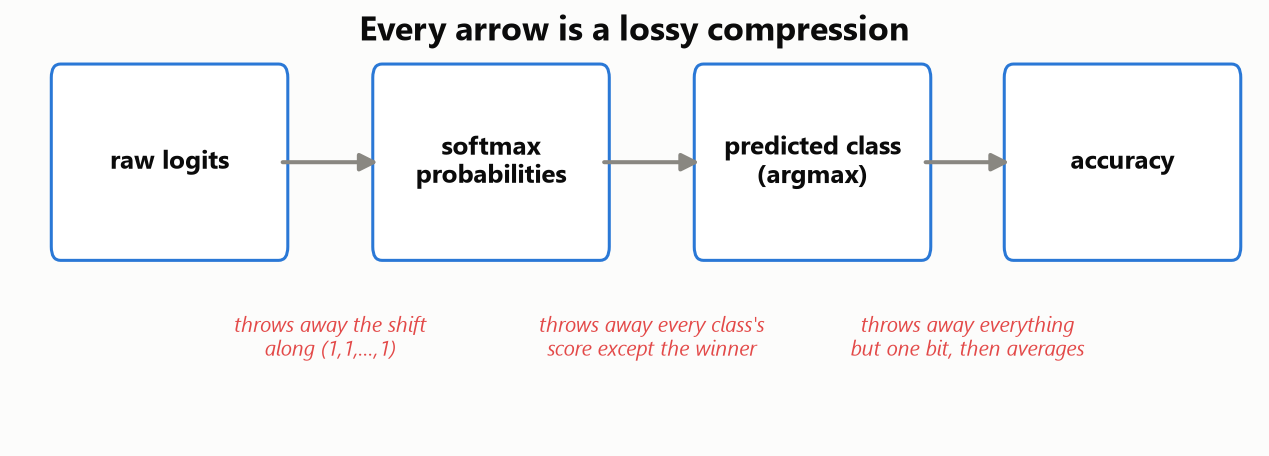

In [17]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# fig01: the lossy pipeline diagram
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.set_xlim(-0.3, 10.5); ax.set_ylim(1.1, 3.35); ax.axis("off")
stages = ["raw logits", "softmax\nprobabilities", "predicted class\n(argmax)", "accuracy"]
losses = ["throws away nothing\n(the starting point)", "throws away the shift\nalong (1,1,...,1)",
          "throws away every class's\nscore except the winner", "throws away everything\nbut one bit, then averages"]
xs = [1.05, 3.85, 6.65, 9.35]
for x, s in zip(xs, stages):
    box = FancyBboxPatch((x - 0.95, 2.25), 1.9, 1.0, boxstyle="round,pad=0.08", linewidth=1.5,
                          edgecolor=CATEGORICAL["blue"], facecolor="white")
    ax.add_patch(box)
    ax.text(x, 2.75, s, ha="center", va="center", fontsize=13, fontweight="bold", color=INK)
for i in range(3):
    ax.add_patch(FancyArrowPatch((xs[i] + 0.95, 2.75), (xs[i + 1] - 0.95, 2.75), arrowstyle="-|>",
                                  mutation_scale=18, linewidth=2, color=INK_MUTED))
    ax.text((xs[i] + xs[i + 1]) / 2, 1.85, losses[i + 1], ha="center", va="top", fontsize=10.5,
            color=CATEGORICAL["red"], style="italic")
ax.set_title("Every arrow is a lossy compression", fontsize=17, fontweight="bold", pad=10)
save_fig(fig, "fig01_lossy_pipeline")
plt.show()


saved D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\fig02_logit_space_3d.png and D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\fig02_logit_space_3d.svg


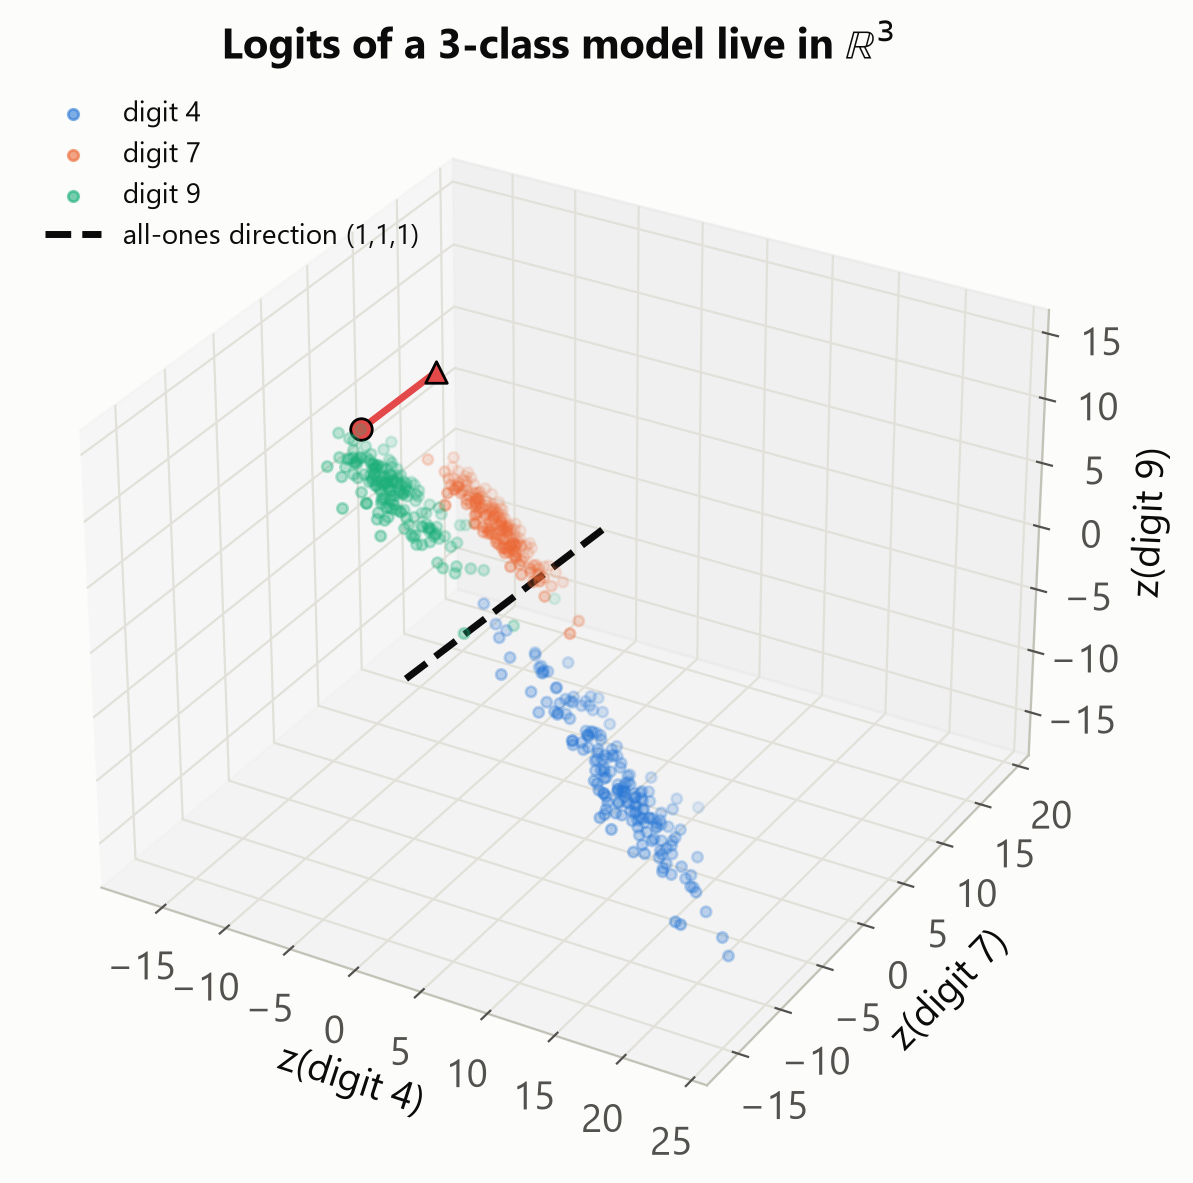

In [18]:
# fig02: 3-class logit space in R^3 with the all-ones direction
d = np.load("artifacts/logits/AUX3_mnist_479_id_test.npz")
logits, labels = d["logits"], d["labels"]
rng = np.random.default_rng(0)
idx = rng.choice(len(logits), size=min(500, len(logits)), replace=False)
z, y = logits[idx], labels[idx]

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
class_names, colors = ["4", "7", "9"], [CATEGORICAL["blue"], CATEGORICAL["orange"], CATEGORICAL["aqua"]]
for c in range(3):
    m = y == c
    ax.scatter(z[m, 0], z[m, 1], z[m, 2], s=14, alpha=0.6, color=colors[c], label=f"digit {class_names[c]}")
center = z.mean(axis=0)
direction = np.ones(3) / np.sqrt(3)
t = np.linspace(-8, 8, 2)
line = center + t[:, None] * direction
ax.plot(line[:, 0], line[:, 1], line[:, 2], color=INK, linewidth=2.5, linestyle="--", label="all-ones direction (1,1,1)")
sample = z[0]; shifted = sample + 6 * direction
ax.plot([sample[0], shifted[0]], [sample[1], shifted[1]], [sample[2], shifted[2]], color=CATEGORICAL["red"], linewidth=2.5)
ax.scatter(*sample, color=CATEGORICAL["red"], s=60, marker="o", edgecolor="black", zorder=5)
ax.scatter(*shifted, color=CATEGORICAL["red"], s=60, marker="^", edgecolor="black", zorder=5)
ax.set_xlabel("z(digit 4)"); ax.set_ylabel("z(digit 7)"); ax.set_zlabel("z(digit 9)")
ax.set_title("Logits of a 3-class model live in $\\mathbb{R}^3$", fontsize=15, fontweight="bold")
ax.legend(loc="upper left", fontsize=10)
save_fig(fig, "fig02_logit_space_3d")
plt.show()


saved D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\fig03_probability_simplex.png and D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\fig03_probability_simplex.svg


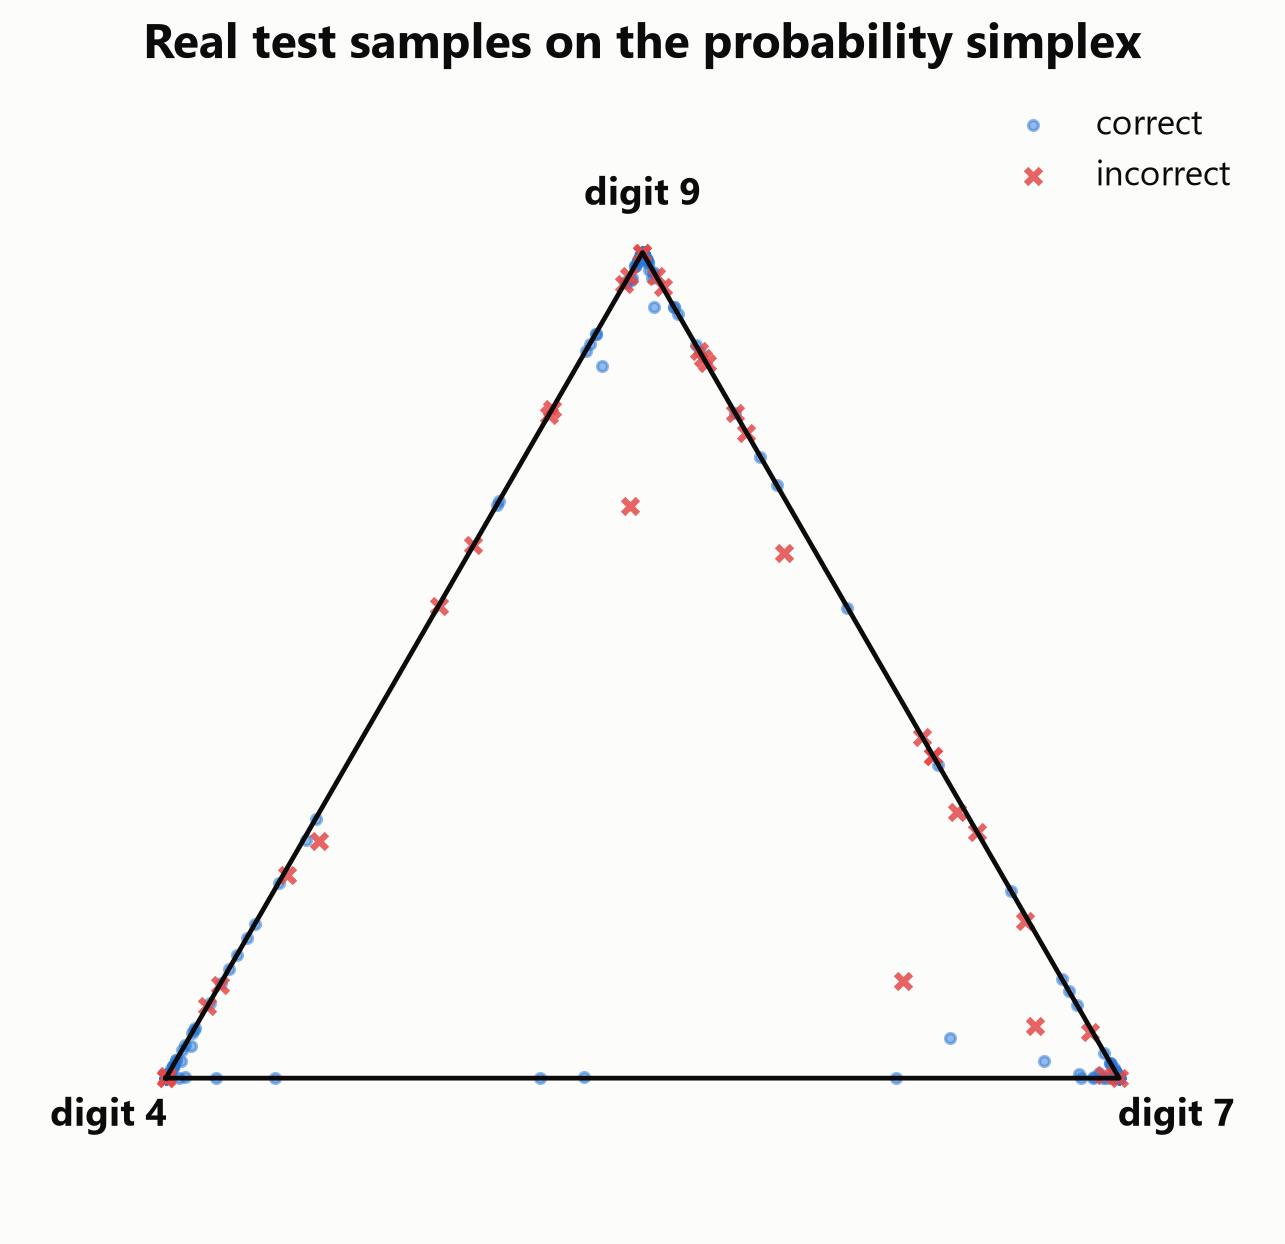

In [19]:
# fig03: the probability simplex (triangle)
def to_simplex_xy(p):
    v = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3) / 2]])
    return p @ v

def draw_simplex_frame(ax):
    v = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3) / 2], [0, 0]])
    ax.plot(v[:, 0], v[:, 1], color=INK, linewidth=1.5)
    for (x, y), lab in zip([(-0.06, -0.05), (1.06, -0.05), (0.5, np.sqrt(3) / 2 + 0.05)], ["digit 4", "digit 7", "digit 9"]):
        ax.text(x, y, lab, ha="center", fontsize=12, fontweight="bold")
    ax.set_xlim(-0.15, 1.15); ax.set_ylim(-0.15, 1.05); ax.set_aspect("equal"); ax.axis("off")

d = np.load("artifacts/logits/AUX3_mnist_479_id_test.npz")
probs = softmax_probs(d["logits"])
pred = probs.argmax(1)
correct3 = pred == d["labels"]
xy = to_simplex_xy(probs)

fig, ax = plt.subplots(figsize=(7, 6.5))
draw_simplex_frame(ax)
ax.scatter(xy[correct3, 0], xy[correct3, 1], s=10, alpha=0.5, color=CORRECT_COLOR, label="correct")
ax.scatter(xy[~correct3, 0], xy[~correct3, 1], s=22, alpha=0.85, color=INCORRECT_COLOR, marker="x", label="incorrect")
ax.set_title("Real test samples on the probability simplex", fontsize=15, fontweight="bold")
ax.legend(loc="upper right", fontsize=11)
save_fig(fig, "fig03_probability_simplex")
plt.show()


saved D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\fig04_temperature_simplex_trajectories.png and D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\fig04_temperature_simplex_trajectories.svg


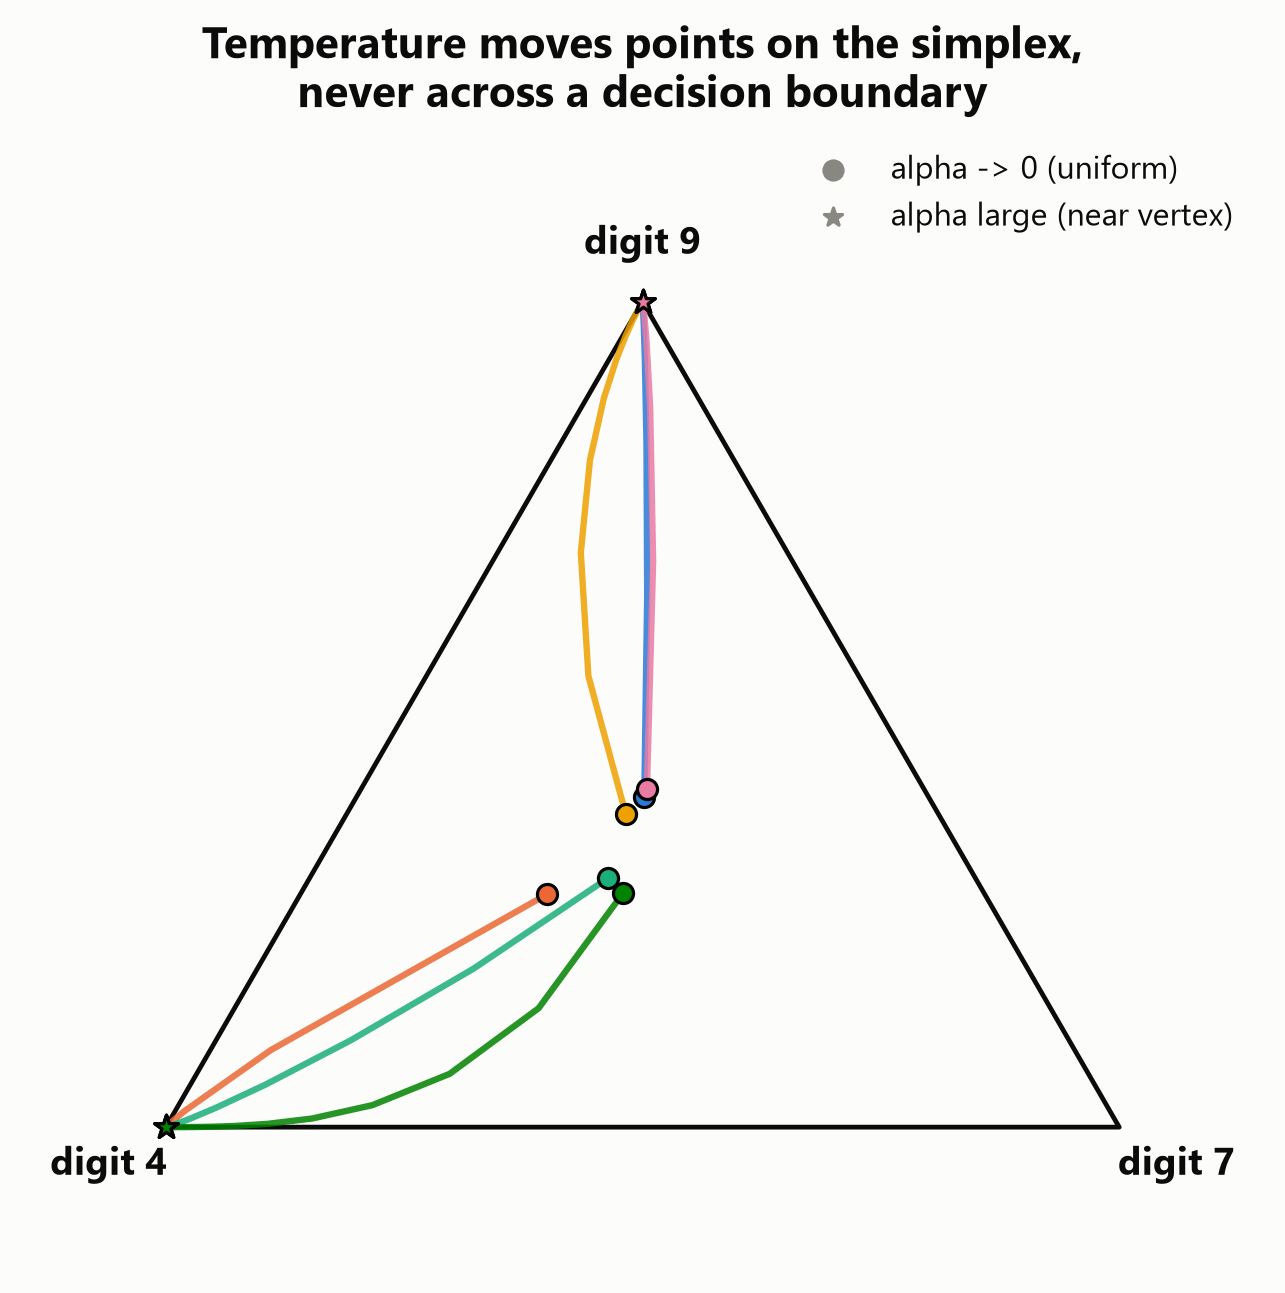

In [20]:
# fig04: temperature as motion on the simplex
rng = np.random.default_rng(1)
sel = rng.choice(len(d["logits"]), size=6, replace=False)
alphas = np.concatenate([np.linspace(0.02, 1, 15), np.linspace(1, 8, 25)])

fig, ax = plt.subplots(figsize=(7, 6.5))
draw_simplex_frame(ax)
for i, sidx in enumerate(sel):
    z = d["logits"][sidx]
    traj = np.array([softmax_probs(a * z[None, :])[0] for a in alphas])
    xy_t = to_simplex_xy(traj)
    color = CAT_LIST[i % len(CAT_LIST)]
    ax.plot(xy_t[:, 0], xy_t[:, 1], color=color, linewidth=2, alpha=0.85)
    ax.scatter(*xy_t[0], color=color, s=40, marker="o", edgecolor="black", zorder=5)
    ax.scatter(*xy_t[-1], color=color, s=60, marker="*", edgecolor="black", zorder=5)
ax.scatter([], [], color=INK_MUTED, marker="o", label="alpha -> 0 (uniform)")
ax.scatter([], [], color=INK_MUTED, marker="*", label="alpha large (near vertex)")
ax.set_title("Temperature moves points on the simplex,\nnever across a decision boundary", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
save_fig(fig, "fig04_temperature_simplex_trajectories")
plt.show()


saved D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\fig05_margin_geometry_2d.png and D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\fig05_margin_geometry_2d.svg


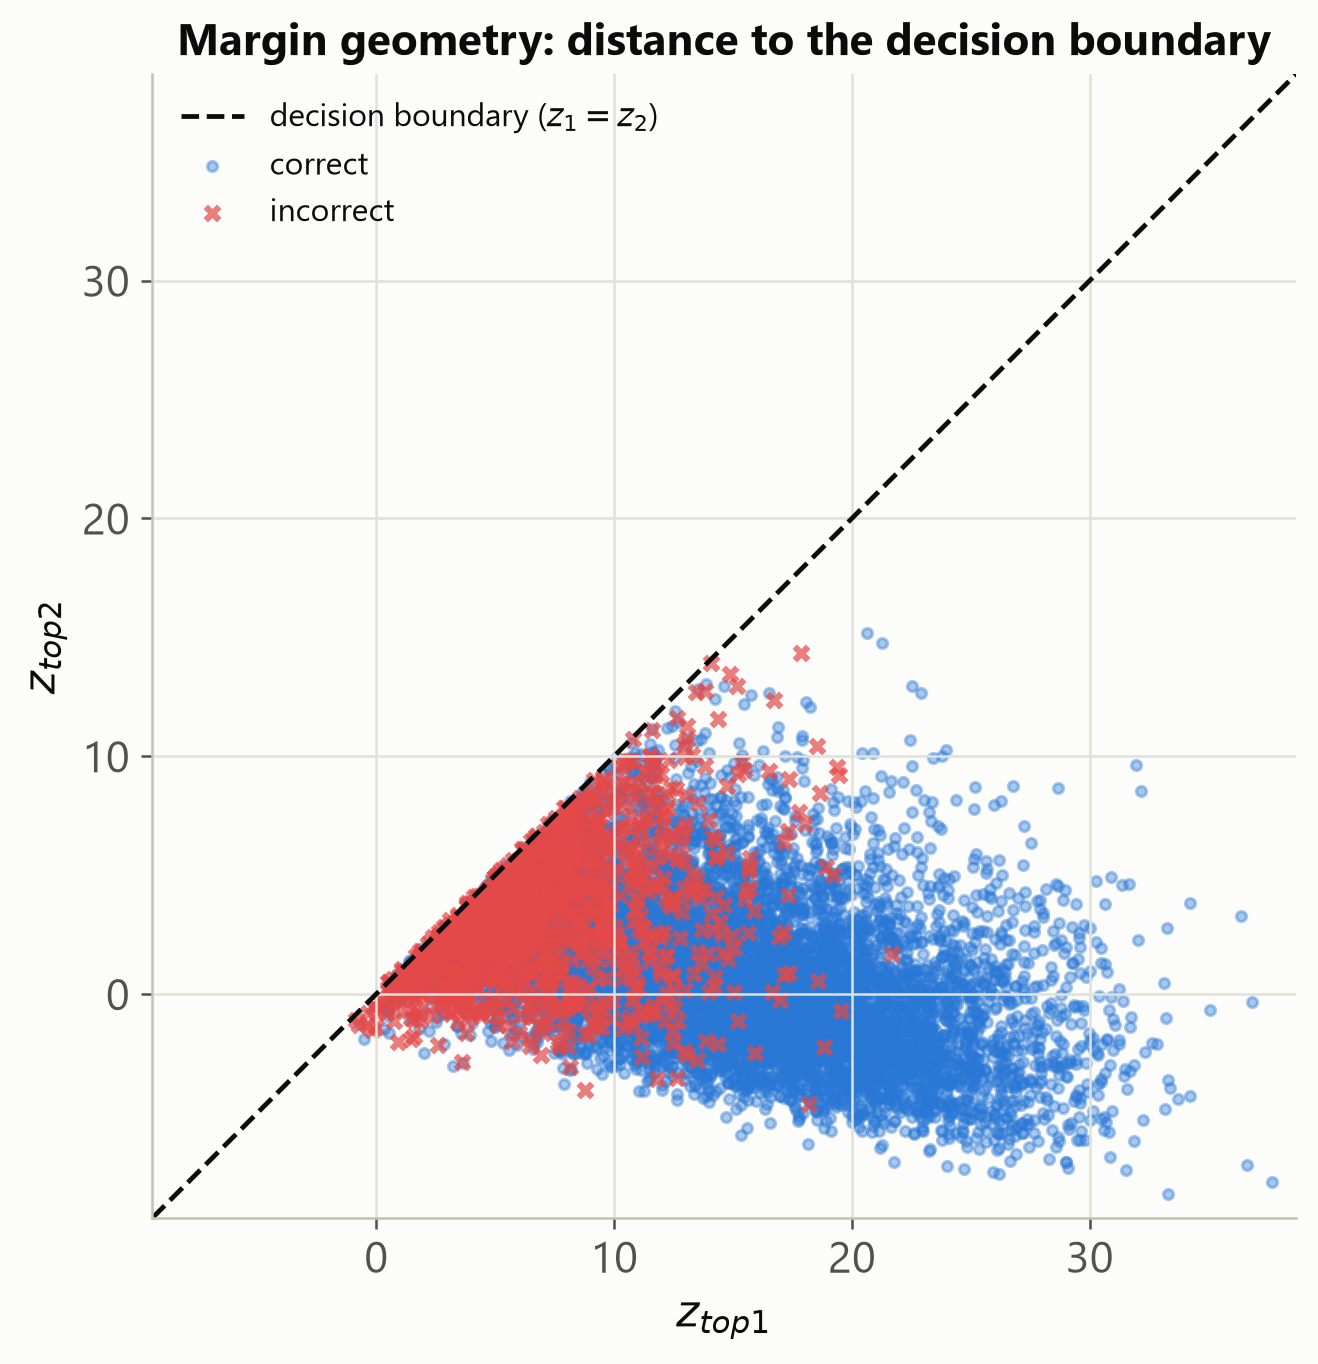

saved D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\fig06_sigmoid_of_margin.png and D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\fig06_sigmoid_of_margin.svg


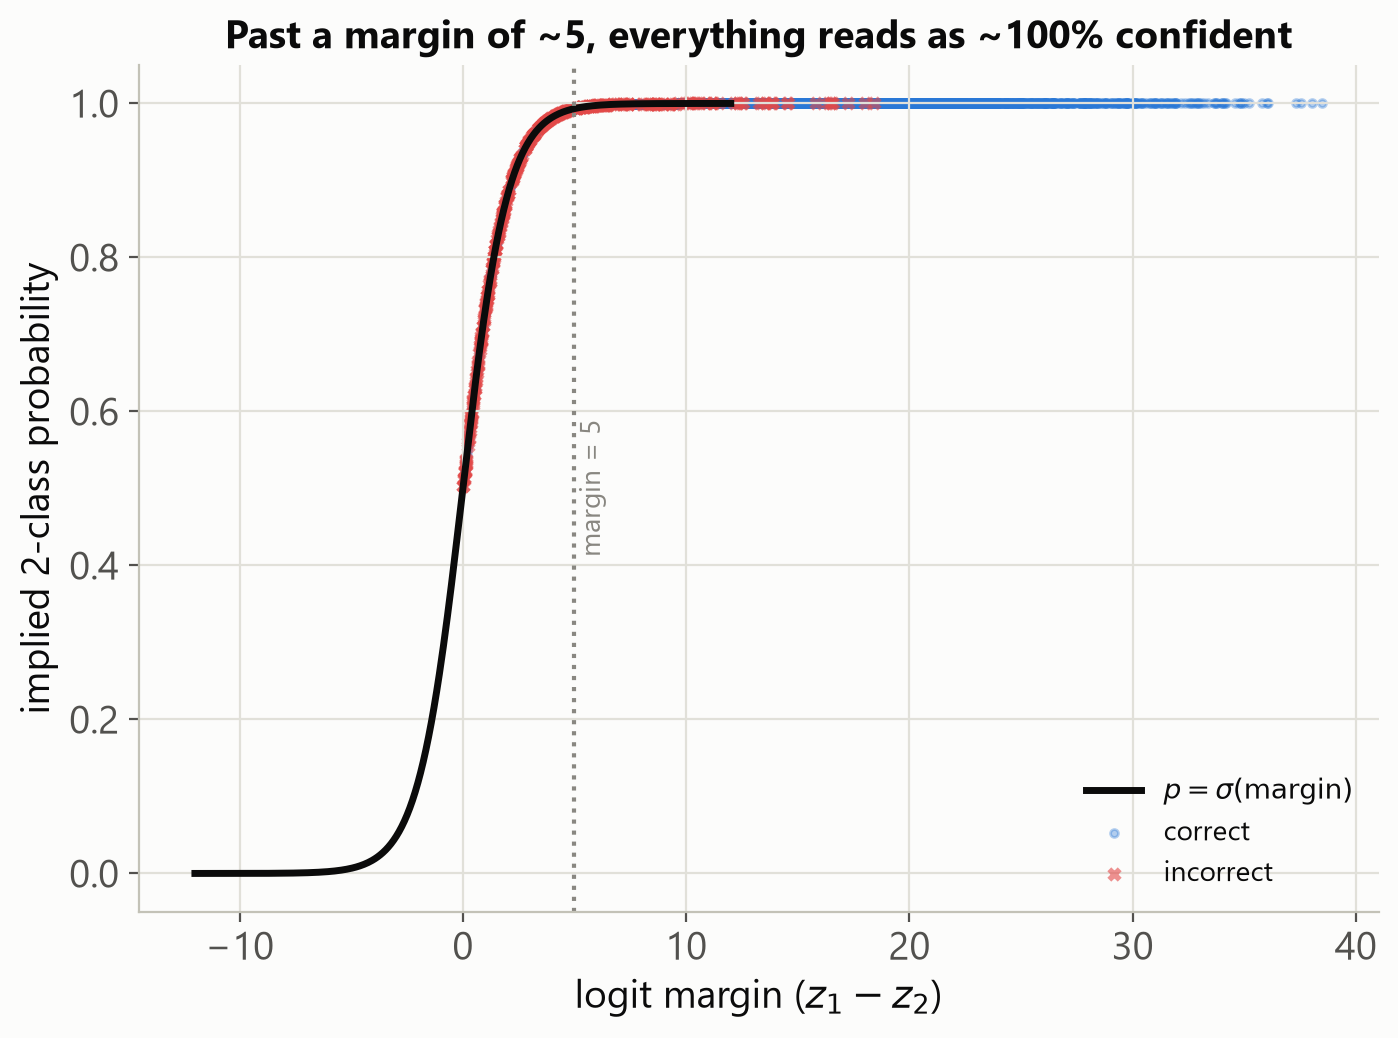

In [21]:
# fig05: margin geometry in 2D (z1 vs z2), fig06: sigmoid of margin
tag = "E_cifar10_resnet18"
test = np.load(f"artifacts/logits/{tag}_id_test.npz")
logits = test["logits"]
probs = softmax_probs(logits)
pred = probs.argmax(1)
correct = pred == test["labels"]
order = np.argsort(-logits, axis=1)
z1 = logits[np.arange(len(pred)), order[:, 0]]
z2 = logits[np.arange(len(pred)), order[:, 1]]
margin = z1 - z2

fig, ax = plt.subplots(figsize=(7, 6.5))
lims = [min(z1.min(), z2.min()) - 1, max(z1.max(), z2.max()) + 1]
ax.plot(lims, lims, color=INK, linestyle="--", linewidth=1.5, label="decision boundary ($z_1=z_2$)")
ax.scatter(z1[correct], z2[correct], s=10, alpha=0.4, color=CORRECT_COLOR, label="correct")
ax.scatter(z1[~correct], z2[~correct], s=18, alpha=0.7, color=INCORRECT_COLOR, marker="x", label="incorrect")
ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
ax.set_xlabel("$z_{top1}$"); ax.set_ylabel("$z_{top2}$")
ax.set_title("Margin geometry: distance to the decision boundary", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=10)
save_fig(fig, "fig05_margin_geometry_2d")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5.5))
m_grid = np.linspace(-12, 12, 400)
ax.plot(m_grid, 1 / (1 + np.exp(-m_grid)), color=INK, linewidth=2.5, label="$p=\\sigma(\\mathrm{margin})$")
rng = np.random.default_rng(0)
sel = rng.choice(len(margin), size=min(3000, len(margin)), replace=False)
p_sel = 1 / (1 + np.exp(-margin[sel]))
c_sel = correct[sel]
ax.scatter(margin[sel][c_sel], p_sel[c_sel], s=8, alpha=0.35, color=CORRECT_COLOR, label="correct")
ax.scatter(margin[sel][~c_sel], p_sel[~c_sel], s=14, alpha=0.6, color=INCORRECT_COLOR, marker="x", label="incorrect")
ax.axvline(5, color=INK_MUTED, linestyle=":", linewidth=1.5)
ax.text(5.2, 0.5, "margin = 5", rotation=90, va="center", fontsize=10, color=INK_MUTED)
ax.set_xlabel("logit margin ($z_1-z_2$)"); ax.set_ylabel("implied 2-class probability")
ax.set_title("Past a margin of ~5, everything reads as ~100% confident", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
save_fig(fig, "fig06_sigmoid_of_margin")
plt.show()


**Interpretation (figures 1-6).** Fig 2 shows the all-ones direction running straight through the logit cloud;
sliding a point 6 units along it (red dot -> triangle) is a large move in R^3 that changes nothing softmax
reports. Fig 3's simplex shows exactly what E1 described numerically: correct predictions pile up at the
vertices, errors concentrate along the edges (contested between two classes), matching the correct/incorrect
split from the per-sample table. Fig 4 shows six real trajectories sliding from the uniform center toward a
vertex as alpha increases — none cross into a different third of the triangle, the geometric picture of the
exact accuracy-invariance measured in E3. Fig 5/6 show why margin and confidence look so similar in E5: once the
margin passes roughly 5, the sigmoid is already past 0.99, so most of the "information" in a large margin is
invisible to anything that only reads off the probability.


saved D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\cover_1600x840.png and D:\My_Projects\My_Articles\The Real Face of Accuracy\logits-blog\figures\cover_1600x840.svg


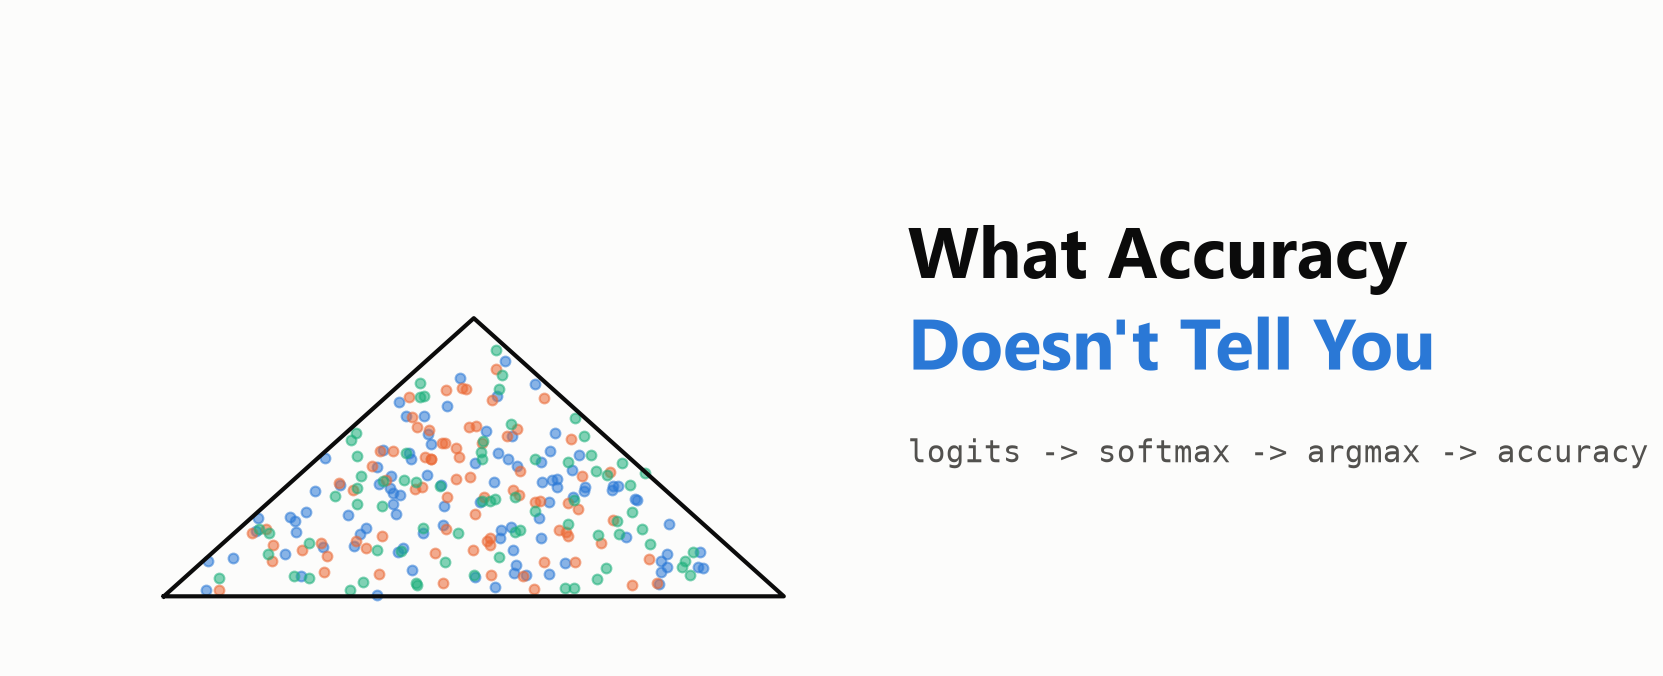

In [22]:
# cover image, 1600x840
fig, ax = plt.subplots(figsize=(1600/150, 840/150), dpi=150)
ax.axis("off"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
rng = np.random.default_rng(3)
v = np.array([[0.12, 0.1], [0.62, 0.1], [0.37, 0.53]])
ax.plot(*np.vstack([v, v[0]]).T, color=INK, linewidth=2)
pts = rng.dirichlet([1.3, 1.3, 1.3], size=250) @ v
colors = [CATEGORICAL["blue"], CATEGORICAL["orange"], CATEGORICAL["aqua"]]
c_idx = rng.integers(0, 3, size=250)
for i in range(3):
    m = c_idx == i
    ax.scatter(pts[m, 0], pts[m, 1], s=22, alpha=0.55, color=colors[i])
ax.text(0.72, 0.62, "What Accuracy", fontsize=34, fontweight="bold", color=INK, ha="left", va="center")
ax.text(0.72, 0.48, "Doesn't Tell You", fontsize=34, fontweight="bold", color=CATEGORICAL["blue"], ha="left", va="center")
ax.text(0.72, 0.32, "logits -> softmax -> argmax -> accuracy", fontsize=15, color=INK_SECONDARY, ha="left", va="center", family="monospace")
save_fig(fig, "cover_1600x840", width_px=1600)
plt.show()


All 11 required geometry figures plus the cover image are exported to `figures/` as matched PNG (2x DPI, ~1600px
wide) and SVG pairs, drawn with a single shared style (`src/plots.py`): light background, a fixed colorblind-safe
categorical palette, and >=14pt fonts at export size. `figures/CAPTIONS.md` lists filename -> caption -> blog
section -> alt text for every figure (written separately, see repo).


---

## Notebook complete — Phase 3 checkpoint

This notebook stops here per the project brief: the findings summary, the E6/E9 tables, the figure list, a
proposed post outline, and title options are sent separately for review before any blog prose is drafted.
